# **Figures and Tables**

## **Imports**

In [1]:
import sys
import os
from pathlib import Path
from typing import Dict
import numpy as np
import pandas as pd

if '../../src/' not in sys.path:
    sys.path.append("../../src/")

from modules.utils.tables.functions import getDfIfFileExist, saveTable
from modules.dataset.functions import assignAsMinPair, get_pairs_w_residues

from modules.dataset.table_summary import build_descriptive_statistics_table

from modules.plots.boxplot_comparison import plot_boxplot_comparison
from modules.plots.plot_faceted_category_scatter import plotFacetedCategoryScatter
from modules.plots.plot_contact_position_proportion_series import plotContactPositionProportionSeries
from modules.plots.plot_bi_panel_metrics import plotBiPanelMetrics
from modules.plots.plot_categorical_bubbles_rna import plotCategoricalBubblesRNA
from modules.plots.plot_cluster_upset import plotClusterUpSet, prepareClusterIndicators
from modules.plots.plot_experimental_methods_venn import plotExperimentalMethodsVenn
from modules.plots.plot_rna_conformer_ligand_bidirectional import plotRnaConformerLigandBidirectional
from modules.plots.plot_grouped_bar_distribution import plotGroupedBarDistribution


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from modules.plots.plot_rna_partner_frequency_sum import plotRnaPartnerFrequencySum
from modules.plots.save_plot_decorator import savePlotDecorator

### **Settings pandas**

https://pandas.pydata.org/pandas-docs/stable/user_guide/options.html

#### The API is composed of 5 relevant functions, available directly from the pandas namespace:

get/set the value of a single option.
+ **get_option() / set_option()**

reset one or more options to their default value.
+ **reset_option()**

print the descriptions of one or more options.
+ **describe_option()**

execute a codeblock with a set of options that revert to prior settings after execution.
+ **option_context()**

In [4]:
# Content and dimensions of dataframe using full “dotted-style”.
#pd.options.display.encoding = UTF-8
pd.options.display.max_columns   = None
pd.options.display.max_colwidth  = 50
pd.options.display.max_rows      = 200
pd.options.display.min_rows      = 10
pd.options.display.max_seq_items = 100
pd.options.display.precision     = 16        #Floating: number of places after the decimal, for regular formatting as well as scientific notation.
pd.options.display.width         = 80
#pd.options.plotting.backend = matplotlib
#pd.options.plotting.matplotlib.register_converters = True

## **Global variables**

In [5]:
# Directories
DATA_DIR           = Path("../../data/")
DATA_PROCESSED_DIR = f"{DATA_DIR}/processed/"
DATA_OUTPUT_DIR    = f"{DATA_DIR}/output/"

RESULTS_DIR         = Path("../../results/")
RESULTS_FIGURES_DIR = f"{RESULTS_DIR}/figures/"
RESULTS_TABLES_DIR  = f"{RESULTS_DIR}/tables/"

### **Style of results**

In [6]:
FIGURE_DPI_VALUE                    = 300
FIGURE_FORMAT                       = "png"
FIGURE_BACKGROUND_COLOR             = "white"
FIGURE_BACKGROUND_COLOR_TRANSPARENT = False

TABLE_FORMAT    = "tsv"
TABLE_SEPARATOR = "\t"
TABLE_ENCODING  = "utf-8"
TABLE_INDEX     = False
TABLE_HEADER    = True
TABLE_NA_VALUES = ""
TABLE_QUOTE     = False

In [7]:
# Applied once, right after the function definition (or in a separate cell)
plotBiPanelMetrics                  = savePlotDecorator(dpi=FIGURE_DPI_VALUE, output_dir=f"{RESULTS_FIGURES_DIR}")(plotBiPanelMetrics)
plotRnaConformerLigandBidirectional = savePlotDecorator(dpi=FIGURE_DPI_VALUE, output_dir=f"{RESULTS_FIGURES_DIR}")(plotRnaConformerLigandBidirectional)
plotCategoricalBubblesRNA           = savePlotDecorator(dpi=FIGURE_DPI_VALUE, output_dir=f"{RESULTS_FIGURES_DIR}")(plotCategoricalBubblesRNA)
plotContactPositionProportionSeries = savePlotDecorator(dpi=FIGURE_DPI_VALUE, output_dir=f"{RESULTS_FIGURES_DIR}")(plotContactPositionProportionSeries)
plotGroupedBarDistribution          = savePlotDecorator(dpi=FIGURE_DPI_VALUE, output_dir=f"{RESULTS_FIGURES_DIR}")(plotGroupedBarDistribution)
plotExperimentalMethodsVenn         = savePlotDecorator(dpi=FIGURE_DPI_VALUE, output_dir=f"{RESULTS_FIGURES_DIR}")(plotExperimentalMethodsVenn)
plotClusterUpSet                    = savePlotDecorator(dpi=FIGURE_DPI_VALUE, output_dir=f"{RESULTS_FIGURES_DIR}")(plotClusterUpSet)
plotRnaPartnerFrequencySum          = savePlotDecorator(dpi=FIGURE_DPI_VALUE, output_dir=f"{RESULTS_FIGURES_DIR}")(plotRnaPartnerFrequencySum)
plotFacetedCategoryScatter          = savePlotDecorator(dpi=FIGURE_DPI_VALUE, output_dir=f"{RESULTS_FIGURES_DIR}")(plotFacetedCategoryScatter)
plot_boxplot_comparison             = savePlotDecorator(dpi=FIGURE_DPI_VALUE, output_dir=f"{RESULTS_FIGURES_DIR}")(plot_boxplot_comparison)

## **Load tables of initial dataset**

### **Dataset clusters**

In [8]:
dataset_clusters_initial = getDfIfFileExist(  df_name     = "dataset_clusters_initial"
                                            , afile       = f"{DATA_PROCESSED_DIR}/initial_dataset_clusters.tsv.gz"
                                            , a_separator = "\t"
                                            , nan_status  = False )
dataset_clusters_initial.replace(to_replace=[''], value=np.nan, inplace=True)
dataset_clusters_initial = dataset_clusters_initial.astype({  'cluster_id'         : 'Int64'
                                                            , 'max_rmsd'           : 'float64'
                                                            , 'cluster_size'       : 'Int64'
                                                            , 'consensus_length'   : 'Int64'
                                                            , 'perc_holo'          : 'float64'
                                                            , 'perc_apo'           : 'float64'
                                                            , 'perc_xrd'           : 'float64'
                                                            , 'perc_em'            : 'float64'
                                                            , 'perc_nmr'           : 'float64' })

In [9]:
dataset_clusters_initial.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 954 entries, 0 to 953
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   cluster_id          954 non-null    Int64  
 1   rna_type_cdrna      954 non-null    object 
 2   max_rmsd            954 non-null    float64
 3   cluster_size        954 non-null    Int64  
 4   conformers_removed  954 non-null    object 
 5   consensus_length    954 non-null    Int64  
 6   perc_holo           954 non-null    float64
 7   perc_apo            954 non-null    float64
 8   perc_xrd            954 non-null    float64
 9   perc_em             954 non-null    float64
 10  perc_nmr            954 non-null    float64
dtypes: Int64(3), float64(6), object(2)
memory usage: 85.0+ KB


### **Dataset conformers**

In [10]:
dataset_conformers_initial = getDfIfFileExist(df_name       = "dataset_conformers_initial"
                                            , afile         = f"{DATA_PROCESSED_DIR}/initial_dataset_conformers.tsv.gz"
                                            , a_separator   = "\t"
                                            , nan_status    = False )
dataset_conformers_initial.replace(to_replace=[''], value=np.nan, inplace=True)
dataset_conformers_initial = dataset_conformers_initial.astype({  'cluster_id'                        : 'Int64'
                                                                , 'resolution'                        : 'float64'
                                                                , 'ph'                                : 'float64'
                                                                , 'seqres_length'                     : 'Int64'
                                                                , 'consensus_start'                   : 'Int64'
                                                                , 'consensus_end'                     : 'Int64' })
dataset_conformers_initial['is_holo'] = dataset_conformers_initial['is_holo'] == 'True'

In [11]:
dataset_conformers_initial.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11964 entries, 0 to 11963
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   cluster_id            11964 non-null  Int64  
 1   rna_type_cdrna        11964 non-null  object 
 2   conformer_id_reduced  11964 non-null  object 
 3   resolution            8061 non-null   float64
 4   method                11964 non-null  object 
 5   temperature           9629 non-null   object 
 6   ph                    10841 non-null  float64
 7   seqres_length         11964 non-null  Int64  
 8   consensus_start       11964 non-null  Int64  
 9   consensus_end         11964 non-null  Int64  
 10  ligand_ids            11964 non-null  object 
 11  is_holo               11964 non-null  bool   
dtypes: Int64(4), bool(1), float64(2), object(5)
memory usage: 1.1+ MB


### **Dataset pairs with ligands**

In [12]:
dataset_pairs_initial = getDfIfFileExist( df_name       = "initial_dataset_pairs"
                                        , afile         = f"{DATA_PROCESSED_DIR}/initial_dataset_pairs.tsv.gz"
                                        , a_separator   = "\t"
                                        , nan_status    = False )
dataset_pairs_initial.replace(to_replace=[''], value=np.nan, inplace=True)
dataset_pairs_initial = dataset_pairs_initial.astype({'cluster_id'                  : 'Int64'
                                                    , 'rmsd'                        : 'float'
                                                    , 'tmscore'                     : 'float'
                                                    , 'nb_ligand_ids_1'             : 'Int64'
                                                    , 'nb_ligand_ids_2'             : 'Int64'
                                                    , 'nb_diff_ligands_1'           : 'Int64'
                                                    , 'nb_diff_ligands_2'           : 'Int64'
                                                    , 'nb_ligand_ids_1_cleaned'     : 'Int64'
                                                    , 'nb_ligand_ids_2_cleaned'     : 'Int64'
                                                    , 'nb_diff_ligands_1_cleaned'   : 'Int64'
                                                    , 'nb_diff_ligands_2_cleaned'   : 'Int64'
                                                    , 'jaccard_idx_no_aid_no_metal' : 'Float64'})

In [13]:
dataset_pairs_initial.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 289424 entries, 0 to 289423
Data columns (total 28 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   cluster_id                   289424 non-null  Int64  
 1   rna_type_cdrna               289424 non-null  object 
 2   conformer_id_1               289424 non-null  object 
 3   conformer_id_2               289424 non-null  object 
 4   is_max                       289424 non-null  object 
 5   is_max_new                   289424 non-null  object 
 6   rmsd                         289424 non-null  float64
 7   tmscore                      289424 non-null  float64
 8   method_1                     289424 non-null  object 
 9   method_2                     289424 non-null  object 
 10  ligand_ids_1                 253978 non-null  object 
 11  ligand_ids_2                 256315 non-null  object 
 12  nb_ligand_ids_1              289424 non-null  Int64  
 13 

### **Residues**

In [ ]:
dataset_residues_initial = getDfIfFileExist( df_name       = "initial_dataset_residues"
                                            , afile         = f"{DATA_PROCESSED_DIR}/initial_dataset_residues.tsv.gz"
                                            , a_separator   = "\t"
                                            , nan_status    = False )

In [15]:
dataset_residues_w_interactions_initial = getDfIfFileExist(df_name     = "initial_dataset_residues_w_interactions_initial"
                                                        ,  afile       = f"{DATA_PROCESSED_DIR}/initial_dataset_residues_w_interactions.tsv.gz"
                                                        ,  a_separator = "\t"
                                                        ,  nan_status  = False )
dataset_residues_w_interactions_initial.replace(to_replace=[''], value=np.nan, inplace=True)
dataset_residues_w_interactions_initial = dataset_residues_w_interactions_initial.astype({'cluster_id'              : 'Int64'
                                                                                        , 'label_seq_id_aligned'    : 'Int64'
                                                                                        , 'consensus_start'         : 'Int64'
                                                                                        , 'consensus_end'           : 'Int64'
                                                                                        , 'label_seq_id'            : 'Int64'
                                                                                        , 'auth_seq_id'             : 'Int64'
                                                                                        , 'res_num'                 : 'Int64'
                                                                                        , 'partner_res_num'         : 'Int64' })

### **Ligands**

In [16]:
ligands_w_threshold_initial = getDfIfFileExist(   df_name       = "initial_ligands_w_threshold"
                                                , afile         = f"{DATA_PROCESSED_DIR}ligands_w_threshold.tsv.gz"
                                                , a_separator   = "\t"
                                                , nan_status    = False )
ligands_w_threshold_initial = ligands_w_threshold_initial.astype({'cluster_id'                : 'Int64'})
ligands_w_threshold_initial['is_metal'] = ligands_w_threshold_initial.is_metal == 'True'
ligands_w_threshold_initial['is_crystallization_aid'] = ligands_w_threshold_initial.is_crystallization_aid == 'True'

In [17]:
ligands_w_threshold_initial.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116944 entries, 0 to 116943
Data columns (total 13 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   cluster_id              116944 non-null  Int64 
 1   rna_type_cdrna          116944 non-null  object
 2   entry_id                116944 non-null  object
 3   version                 116944 non-null  object
 4   conformer_id_reduced    116944 non-null  object
 5   partner_id_reduced      116944 non-null  object
 6   partner_rcsb_type       116944 non-null  object
 7   partner_name            116944 non-null  object
 8   identifier              116944 non-null  object
 9   frequency_on_db         116944 non-null  object
 10  frequency_on_cluster    116944 non-null  object
 11  is_metal                116944 non-null  bool  
 12  is_crystallization_aid  116944 non-null  bool  
dtypes: Int64(1), bool(2), object(10)
memory usage: 10.1+ MB


### **Stats**

In [18]:
conformer_stats_initial = getDfIfFileExist(   df_name       = "initial_conformer_stats"
                                            , afile         = f"{DATA_PROCESSED_DIR}/initial_conformer_stats.tsv.gz"
                                            , a_separator   = "\t"
                                            , nan_status    = False )
conformer_stats_initial.replace(to_replace=[''], value=np.nan, inplace=True)
conformer_stats_initial = conformer_stats_initial.astype({'cluster_id'                        : 'Int64'
                                                        , 'label_seq_id_aligned'              : 'Int64'
                                                        , 'label_seq_id'                      : 'Int64'
                                                        , 'auth_seq_id'                       : 'Int64'
                                                        , 'interaction_count_all'             : 'int64'
                                                        , 'interaction_count_no_aid'          : 'int64'
                                                        , 'interaction_count_no_aid_no_metal' : 'int64' })

In [19]:
conformer_stats_initial.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5715551 entries, 0 to 5715550
Data columns (total 16 columns):
 #   Column                             Dtype 
---  ------                             ----- 
 0   cluster_id                         Int64 
 1   conformer_id_reduced               object
 2   label_seq_id_aligned               Int64 
 3   one_letter_code                    object
 4   label_seq_id                       Int64 
 5   label_comp_id                      object
 6   auth_seq_id                        Int64 
 7   auth_comp_id                       object
 8   pdb_ins_code                       object
 9   occupancy_flag                     object
 10  interaction_count_all              int64 
 11  interaction_count_no_aid           int64 
 12  interaction_count_no_aid_no_metal  int64 
 13  ligands_ids_all                    object
 14  ligands_ids_no_aid                 object
 15  ligands_ids_no_aid_no_metal        object
dtypes: Int64(4), int64(3), object(9)
mem

In [20]:
cluster_stats_initial = getDfIfFileExist( df_name     = "initial_cluster_stats"
                                        , afile       = f"{DATA_PROCESSED_DIR}/initial_cluster_stats.tsv.gz"
                                        , a_separator = "\t"
                                        , nan_status  = False )
cluster_stats_initial.replace(to_replace=[''], value=np.nan, inplace=True)
cluster_stats_initial = cluster_stats_initial.astype({'cluster_id'                                              : 'Int64'
                                                    , 'label_seq_id_aligned'                                    : 'Int64'
                                                    , 'cluster_size'                                            : 'int64'
                                                    , 'nb_conformers_w_missing'                                 : 'int64'
                                                    , 'total_holos_all'                                         : 'float64'
                                                    , 'max_interactions_on_position_all'                        : 'float64'
                                                    , 'min_interactions_on_position_all'                        : 'float64'
                                                    , 'avg_interactions_on_position_all'                        : 'float64'
                                                    , 'med_interactions_on_position_all'                        : 'float64'
                                                    , 'std_interactions_on_position_all'                        : 'float64'
                                                    , 'var_interactions_on_position_all'                        : 'float64'
                                                    , 'nb_conformers_with_interactions_all'                     : 'int64'
                                                    , 'nb_conformers_without_interactions_all'                  : 'int64'
                                                    , 'nb_conformers_with_eq_max_interactions_all'              : 'int64'
                                                    , 'nb_conformers_with_gt_avg_interactions_all'              : 'int64'
                                                    , 'nb_conformers_with_gt_med_interactions_all'              : 'int64'
                                                    , 'nb_conformers_with_le_std_interactions_all'              : 'int64'
                                                    , 'nb_conformers_with_le_var_interactions_all'              : 'int64'
                                                    , 'total_holos_no_aid'                                      : 'float64'
                                                    , 'max_interactions_on_position_no_aid'                     : 'float64'
                                                    , 'min_interactions_on_position_no_aid'                     : 'float64'
                                                    , 'avg_interactions_on_position_no_aid'                     : 'float64'
                                                    , 'med_interactions_on_position_no_aid'                     : 'float64'
                                                    , 'std_interactions_on_position_no_aid'                     : 'float64'
                                                    , 'var_interactions_on_position_no_aid'                     : 'float64'
                                                    , 'nb_conformers_with_interactions_no_aid'                  : 'int64'
                                                    , 'nb_conformers_without_interactions_no_aid'               : 'int64'
                                                    , 'nb_conformers_with_eq_max_interactions_no_aid'           : 'int64'
                                                    , 'nb_conformers_with_gt_avg_interactions_no_aid'           : 'int64'
                                                    , 'nb_conformers_with_gt_med_interactions_no_aid'           : 'int64'
                                                    , 'nb_conformers_with_le_std_interactions_no_aid'           : 'int64'
                                                    , 'nb_conformers_with_le_var_interactions_no_aid'           : 'int64'
                                                    , 'total_holos_no_aid_no_metal'                             : 'float64'
                                                    , 'max_interactions_on_position_no_aid_no_metal'            : 'float64'
                                                    , 'min_interactions_on_position_no_aid_no_metal'            : 'float64'
                                                    , 'avg_interactions_on_position_no_aid_no_metal'            : 'float64'
                                                    , 'med_interactions_on_position_no_aid_no_metal'            : 'float64'
                                                    , 'std_interactions_on_position_no_aid_no_metal'            : 'float64'
                                                    , 'var_interactions_on_position_no_aid_no_metal'            : 'float64'
                                                    , 'nb_conformers_with_interactions_no_aid_no_metal'         : 'int64'
                                                    , 'nb_conformers_without_interactions_no_aid_no_metal'      : 'int64'
                                                    , 'nb_conformers_with_eq_max_interactions_no_aid_no_metal'  : 'int64'
                                                    , 'nb_conformers_with_gt_avg_interactions_no_aid_no_metal'  : 'int64'
                                                    , 'nb_conformers_with_gt_med_interactions_no_aid_no_metal'  : 'int64'
                                                    , 'nb_conformers_with_le_std_interactions_no_aid_no_metal'  : 'int64'
                                                    , 'nb_conformers_with_le_var_interactions_no_aid_no_metal'  : 'int64'
                                                    , 'proportional_holo_conservation_score_all'                : 'float64'
                                                    , 'interactions_normalized_by_holos_all'                    : 'float64'
                                                    , 'proportional_holo_conservation_score_no_aid'             : 'float64'
                                                    , 'interactions_normalized_by_holos_no_aid'                 : 'float64'
                                                    , 'proportional_holo_conservation_score_no_aid_no_metal'    : 'float64'
                                                    , 'interactions_normalized_by_holos_no_aid_no_metal'        : 'float64'
                                                    })

In [21]:
cluster_stats_initial.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359492 entries, 0 to 359491
Data columns (total 53 columns):
 #   Column                                                  Non-Null Count   Dtype  
---  ------                                                  --------------   -----  
 0   cluster_id                                              359492 non-null  Int64  
 1   label_seq_id_aligned                                    359492 non-null  Int64  
 2   one_letter_code                                         359492 non-null  object 
 3   cluster_size                                            359492 non-null  int64  
 4   nb_conformers_w_missing                                 359492 non-null  int64  
 5   total_holos_all                                         359492 non-null  float64
 6   max_interactions_on_position_all                        336867 non-null  float64
 7   min_interactions_on_position_all                        336867 non-null  float64
 8   avg_interactions_on_posi

## **Load tables of final dataset**

### **Dataset clusters**

In [22]:
dataset_clusters = getDfIfFileExist(  df_name     = "dataset_clusters"
                                    , afile       = f"{DATA_PROCESSED_DIR}/final_dataset_clusters.tsv.gz"
                                    , a_separator = "\t"
                                    , nan_status  = False )
dataset_clusters.replace(to_replace=[''], value=np.nan, inplace=True)
dataset_clusters = dataset_clusters.astype({  'cluster_id'         : 'Int64'
                                            , 'max_rmsd'           : 'float64'
                                            , 'cluster_size'       : 'Int64'
                                            , 'consensus_length'   : 'Int64'
                                            , 'perc_holo'          : 'float64'
                                            , 'perc_apo'           : 'float64'
                                            , 'perc_xrd'           : 'float64'
                                            , 'perc_em'            : 'float64'
                                            , 'perc_nmr'           : 'float64' })

In [23]:
dataset_clusters.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 213 entries, 0 to 212
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   cluster_id          213 non-null    Int64  
 1   rna_type_cdrna      213 non-null    object 
 2   max_rmsd            213 non-null    float64
 3   cluster_size        213 non-null    Int64  
 4   conformers_removed  213 non-null    object 
 5   consensus_length    213 non-null    Int64  
 6   perc_apo            213 non-null    float64
 7   perc_holo           213 non-null    float64
 8   perc_xrd            213 non-null    float64
 9   perc_em             213 non-null    float64
 10  perc_nmr            213 non-null    float64
dtypes: Int64(3), float64(6), object(2)
memory usage: 19.1+ KB


### **Dataset conformers**

In [24]:
dataset_conformers = getDfIfFileExist(df_name       = "dataset_conformers"
                                    , afile         = f"{DATA_PROCESSED_DIR}/final_dataset_conformers.tsv.gz"
                                    , a_separator   = "\t"
                                    , nan_status    = False )
dataset_conformers.replace(to_replace=[''], value=np.nan, inplace=True)
dataset_conformers = dataset_conformers.astype({  'cluster_id'                        : 'Int64'
                                                , 'resolution'                        : 'float64'
                                                , 'ph'                                : 'float64'
                                                , 'seqres_length'                     : 'Int64'
                                                , 'consensus_start'                   : 'Int64'
                                                , 'consensus_end'                     : 'Int64' })
dataset_conformers['is_holo'] = dataset_conformers['is_holo'] == 'True'

In [25]:
dataset_conformers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8709 entries, 0 to 8708
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   cluster_id            8709 non-null   Int64  
 1   rna_type_cdrna        8709 non-null   object 
 2   conformer_id_reduced  8709 non-null   object 
 3   resolution            4910 non-null   float64
 4   method                8709 non-null   object 
 5   temperature           7251 non-null   object 
 6   ph                    8088 non-null   float64
 7   seqres_length         8709 non-null   Int64  
 8   consensus_start       8709 non-null   Int64  
 9   consensus_end         8709 non-null   Int64  
 10  ligand_ids            8709 non-null   object 
 11  is_holo               8709 non-null   bool   
dtypes: Int64(4), bool(1), float64(2), object(5)
memory usage: 791.1+ KB


In [26]:
final_conformers = dataset_conformers['conformer_id_reduced'].unique().tolist()

### **Dataset pairs with ligands**

In [27]:
dataset_pairs = getDfIfFileExist( df_name       = "final_dataset_pairs"
                                , afile         = f"{DATA_PROCESSED_DIR}final_dataset_pairs.tsv.gz"
                                , a_separator   = "\t"
                                , nan_status    = False )
dataset_pairs.replace(to_replace=[''], value=np.nan, inplace=True)
dataset_pairs = dataset_pairs.astype({'cluster_id'                  : 'Int64'
                                    , 'rmsd'                        : 'float'
                                    , 'tmscore'                     : 'float'
                                    , 'nb_ligand_ids_1'             : 'Int64'
                                    , 'nb_ligand_ids_2'             : 'Int64'
                                    , 'nb_diff_ligands_1'           : 'Int64'
                                    , 'nb_diff_ligands_2'           : 'Int64'
                                    , 'nb_ligand_ids_1_cleaned'     : 'Int64'
                                    , 'nb_ligand_ids_2_cleaned'     : 'Int64'
                                    , 'nb_diff_ligands_1_cleaned'   : 'Int64'
                                    , 'nb_diff_ligands_2_cleaned'   : 'Int64'
                                    , 'jaccard_idx_no_aid_no_metal' : 'Float64'})

In [28]:
dataset_pairs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 283263 entries, 0 to 283262
Data columns (total 28 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   cluster_id                   283263 non-null  Int64  
 1   rna_type_cdrna               283263 non-null  object 
 2   conformer_id_1               283263 non-null  object 
 3   conformer_id_2               283263 non-null  object 
 4   is_max                       283263 non-null  object 
 5   is_max_new                   283263 non-null  object 
 6   rmsd                         283263 non-null  float64
 7   tmscore                      283263 non-null  float64
 8   method_1                     283263 non-null  object 
 9   method_2                     283263 non-null  object 
 10  ligand_ids_1                 248079 non-null  object 
 11  ligand_ids_2                 250444 non-null  object 
 12  nb_ligand_ids_1              283263 non-null  Int64  
 13 

### **Residues**

In [29]:
dataset_residues = dataset_residues_initial.loc[lambda df: df['conformer_id_reduced'].isin(final_conformers)].copy()

In [30]:
dataset_residues_w_interactions = dataset_residues_w_interactions_initial.loc[lambda df: df['conformer_id_reduced'].isin(final_conformers)].copy()

In [31]:
dataset_residues_w_interactions.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6035696 entries, 0 to 8135663
Data columns (total 31 columns):
 #   Column                    Dtype 
---  ------                    ----- 
 0   cluster_id                Int64 
 1   rna_type_cdrna            object
 2   conformer_id_reduced      object
 3   label_seq_id_aligned      Int64 
 4   one_letter_code           object
 5   consensus_start           Int64 
 6   consensus_end             Int64 
 7   label_asym_id             object
 8   label_seq_id              Int64 
 9   label_comp_id             object
 10  auth_seq_id               Int64 
 11  auth_comp_id              object
 12  auth_asym_id              object
 13  pdb_ins_code              object
 14  entity_type               object
 15  occupancy_flag            object
 16  pdbx_PDB_model_num        object
 17  polymer_flag              object
 18  version                   object
 19  deposition_date           object
 20  res_id                    object
 21  res_num      

### **Ligands**

In [ ]:
ligands_w_threshold  =  getDfIfFileExist( df_name       = "final_ligands_w_threshold"
                                        , afile         = f"{DATA_PROCESSED_DIR}/final_ligands_w_threshold.tsv.gz"
                                        , a_separator   = "\t"
                                        , nan_status    = False )
ligands_w_threshold = ligands_w_threshold.astype({'cluster_id'                : 'Int64'})
ligands_w_threshold['is_metal'] = ligands_w_threshold.is_metal == 'True'
ligands_w_threshold['is_crystallization_aid'] = ligands_w_threshold.is_crystallization_aid == 'True'

In [33]:
ligands_w_threshold.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87272 entries, 0 to 87271
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   cluster_id              87272 non-null  Int64 
 1   rna_type_cdrna          87272 non-null  object
 2   entry_id                87272 non-null  object
 3   version                 87272 non-null  object
 4   conformer_id_reduced    87272 non-null  object
 5   partner_id_reduced      87272 non-null  object
 6   partner_rcsb_type       87272 non-null  object
 7   partner_name            87272 non-null  object
 8   identifier              87272 non-null  object
 9   frequency_on_db         87272 non-null  object
 10  frequency_on_cluster    87272 non-null  object
 11  is_metal                87272 non-null  bool  
 12  is_crystallization_aid  87272 non-null  bool  
dtypes: Int64(1), bool(2), object(10)
memory usage: 7.6+ MB


### **Stats**

In [ ]:
conformer_stats = getDfIfFileExist( df_name         = "conformer_stats"
                                    , afile         = f"{DATA_PROCESSED_DIR}/final_conformer_stats.tsv.gz"
                                    , a_separator   = "\t"
                                    , nan_status    = False )
conformer_stats.replace(to_replace=[''], value=np.nan, inplace=True)
conformer_stats = conformer_stats.astype({'cluster_id'                        : 'Int64'
                                        , 'label_seq_id_aligned'              : 'Int64'
                                        , 'label_seq_id'                      : 'Int64'
                                        , 'auth_seq_id'                       : 'Int64'
                                        , 'interaction_count_all'             : 'int64'
                                        , 'interaction_count_no_aid'          : 'int64'
                                        , 'interaction_count_no_aid_no_metal' : 'int64' })

In [35]:
conformer_stats.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4234224 entries, 0 to 4234223
Data columns (total 16 columns):
 #   Column                             Dtype 
---  ------                             ----- 
 0   cluster_id                         Int64 
 1   conformer_id_reduced               object
 2   label_seq_id_aligned               Int64 
 3   one_letter_code                    object
 4   label_seq_id                       Int64 
 5   label_comp_id                      object
 6   auth_seq_id                        Int64 
 7   auth_comp_id                       object
 8   pdb_ins_code                       object
 9   occupancy_flag                     object
 10  interaction_count_all              int64 
 11  interaction_count_no_aid           int64 
 12  interaction_count_no_aid_no_metal  int64 
 13  ligands_ids_all                    object
 14  ligands_ids_no_aid                 object
 15  ligands_ids_no_aid_no_metal        object
dtypes: Int64(4), int64(3), object(9)
mem

In [36]:
cluster_stats = getDfIfFileExist( df_name     = "cluster_stats"
                                , afile       = f"{DATA_PROCESSED_DIR}/final_cluster_stats.tsv.gz"
                                , a_separator = "\t"
                                , nan_status  = False )
cluster_stats.replace(to_replace=[''], value=np.nan, inplace=True)
cluster_stats = cluster_stats.astype({'cluster_id'                                              : 'Int64'
                                    , 'label_seq_id_aligned'                                    : 'Int64'
                                    , 'cluster_size'                                            : 'int64'
                                    , 'nb_conformers_w_missing'                                 : 'int64'
                                    , 'total_holos_all'                                         : 'float64'
                                    , 'max_interactions_on_position_all'                        : 'float64'
                                    , 'min_interactions_on_position_all'                        : 'float64'
                                    , 'avg_interactions_on_position_all'                        : 'float64'
                                    , 'med_interactions_on_position_all'                        : 'float64'
                                    , 'std_interactions_on_position_all'                        : 'float64'
                                    , 'var_interactions_on_position_all'                        : 'float64'
                                    , 'nb_conformers_with_interactions_all'                     : 'int64'
                                    , 'nb_conformers_without_interactions_all'                  : 'int64'
                                    , 'nb_conformers_with_eq_max_interactions_all'              : 'int64'
                                    , 'nb_conformers_with_gt_avg_interactions_all'              : 'int64'
                                    , 'nb_conformers_with_gt_med_interactions_all'              : 'int64'
                                    , 'nb_conformers_with_le_std_interactions_all'              : 'int64'
                                    , 'nb_conformers_with_le_var_interactions_all'              : 'int64'
                                    , 'total_holos_no_aid'                                      : 'float64'
                                    , 'max_interactions_on_position_no_aid'                     : 'float64'
                                    , 'min_interactions_on_position_no_aid'                     : 'float64'
                                    , 'avg_interactions_on_position_no_aid'                     : 'float64'
                                    , 'med_interactions_on_position_no_aid'                     : 'float64'
                                    , 'std_interactions_on_position_no_aid'                     : 'float64'
                                    , 'var_interactions_on_position_no_aid'                     : 'float64'
                                    , 'nb_conformers_with_interactions_no_aid'                  : 'int64'
                                    , 'nb_conformers_without_interactions_no_aid'               : 'int64'
                                    , 'nb_conformers_with_eq_max_interactions_no_aid'           : 'int64'
                                    , 'nb_conformers_with_gt_avg_interactions_no_aid'           : 'int64'
                                    , 'nb_conformers_with_gt_med_interactions_no_aid'           : 'int64'
                                    , 'nb_conformers_with_le_std_interactions_no_aid'           : 'int64'
                                    , 'nb_conformers_with_le_var_interactions_no_aid'           : 'int64'
                                    , 'total_holos_no_aid_no_metal'                             : 'float64'
                                    , 'max_interactions_on_position_no_aid_no_metal'            : 'float64'
                                    , 'min_interactions_on_position_no_aid_no_metal'            : 'float64'
                                    , 'avg_interactions_on_position_no_aid_no_metal'            : 'float64'
                                    , 'med_interactions_on_position_no_aid_no_metal'            : 'float64'
                                    , 'std_interactions_on_position_no_aid_no_metal'            : 'float64'
                                    , 'var_interactions_on_position_no_aid_no_metal'            : 'float64'
                                    , 'nb_conformers_with_interactions_no_aid_no_metal'         : 'int64'
                                    , 'nb_conformers_without_interactions_no_aid_no_metal'      : 'int64'
                                    , 'nb_conformers_with_eq_max_interactions_no_aid_no_metal'  : 'int64'
                                    , 'nb_conformers_with_gt_avg_interactions_no_aid_no_metal'  : 'int64'
                                    , 'nb_conformers_with_gt_med_interactions_no_aid_no_metal'  : 'int64'
                                    , 'nb_conformers_with_le_std_interactions_no_aid_no_metal'  : 'int64'
                                    , 'nb_conformers_with_le_var_interactions_no_aid_no_metal'  : 'int64'
                                    , 'proportional_holo_conservation_score_all'                : 'float64'
                                    , 'interactions_normalized_by_holos_all'                    : 'float64'
                                    , 'proportional_holo_conservation_score_no_aid'             : 'float64'
                                    , 'interactions_normalized_by_holos_no_aid'                 : 'float64'
                                    , 'proportional_holo_conservation_score_no_aid_no_metal'    : 'float64'
                                    , 'interactions_normalized_by_holos_no_aid_no_metal'        : 'float64'
                                    })

In [37]:
cluster_stats.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67027 entries, 0 to 67026
Data columns (total 53 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   cluster_id                                              67027 non-null  Int64  
 1   label_seq_id_aligned                                    67027 non-null  Int64  
 2   one_letter_code                                         67027 non-null  object 
 3   cluster_size                                            67027 non-null  int64  
 4   nb_conformers_w_missing                                 67027 non-null  int64  
 5   total_holos_all                                         67027 non-null  float64
 6   max_interactions_on_position_all                        66775 non-null  float64
 7   min_interactions_on_position_all                        66775 non-null  float64
 8   avg_interactions_on_position_all    

## **Load table C3' RMSD of cluster 100**

In [38]:
df_rmsd_c3_prime  =  getDfIfFileExist(df_name     = "df_rmsd_c3_prime"
                                    , afile       = f"{DATA_PROCESSED_DIR}rmsd_c3_prime_per_position.tsv.gz"
                                    , a_separator = "\t"
                                    , nan_status  = False )
df_rmsd_c3_prime = df_rmsd_c3_prime.astype({  'res_num': 'Int64'
                                            , 'rmsd-2kx5_1_A_3-vs-1anr_1_A_6': 'float64'
                                            , 'rmsd-2kx5_1_A_3-vs-1anr_1_A_8': 'float64'
                                            , 'rmsd-1anr_1_A_6-vs-1anr_1_A_8': 'float64' })

## **Plots**

### **Groups**

In [ ]:
#######################
#   RNA type groups   #
#######################

rna_types_grouped = { 'transcript'     : 'transcript'
                    , 'rRNA'           : 'rRNA'
                    , 'tRNA'           : 'tRNA'
                    , 'mRNA'           : 'mRNA'
                    , 'riboswitch'     : 'riboswitch'
                    , 'enzymatic'      : 'enzymatic'
                    , 'snRNA'          : 'other'
                    , 'ncRNA'          : 'other'
                    , 'intron'         : 'other'
                    , 'SRP_RNA'        : 'other'
                    , 'piRNA'          : 'other'
                    , 'miRNA'          : 'other'
                    , 'tmRNA'          : 'other'
                    , 'snoRNA'         : 'other'
                    , 'telomerase_RNA' : 'other'
                    , 'unknown'        : 'unknown'
}

rna_types_grouped_others = {  'transcript'     : 'transcript'
                            , 'rRNA'           : 'rRNA'
                            , 'tRNA'           : 'tRNA'
                            , 'mRNA'           : 'others'
                            , 'riboswitch'     : 'others'
                            , 'enzymatic'      : 'others'
                            , 'snRNA'          : 'others'
                            , 'ncRNA'          : 'others'
                            , 'intron'         : 'others'
                            , 'SRP_RNA'        : 'others'
                            , 'piRNA'          : 'others'
                            , 'miRNA'          : 'others'
                            , 'tmRNA'          : 'others'
                            , 'snoRNA'         : 'others'
                            , 'telomerase_RNA' : 'others'
                            , 'unknown'        : 'others'
}

#####################
#   Ligand groups   #
#####################

biomolecules_classification_grouped = {
    'polypeptide(L)'                                    : 'protein',
    'polypeptide(D)'                                    : 'protein',
    'polyribonucleotide'                                : 'rna',
    'polydeoxyribonucleotide'                           : 'others',
    'polydeoxyribonucleotide/polyribonucleotide hybrid' : 'others',
    'nonpolymer'                                        : 'nonpolymer',
    'oligosaccharide'                                   : 'others',
    'other'                                             : 'others',
}

In [40]:
#####################
#   Method groups   #
#####################
choices = ["X-RAY DIFFRACTION", "ELECTRON MICROSCOPY", "SOLUTION NMR"]

conditions = [
    dataset_clusters["perc_xrd"] == 100,
    dataset_clusters["perc_em"]  == 100,
    dataset_clusters["perc_nmr"] == 100,
]
dataset_clusters["method_grouped"] = np.select(conditions, choices, default="MIXED")

conditions_initial = [
    dataset_clusters_initial["perc_xrd"] == 100,
    dataset_clusters_initial["perc_em"]  == 100,
    dataset_clusters_initial["perc_nmr"] == 100,
]
dataset_clusters_initial["method_grouped"] = np.select(conditions_initial, choices, default="MIXED")

In [41]:
# RNA type grouping
dataset_conformers['rna_type_cdrna_grouped']  = dataset_conformers['rna_type_cdrna'].replace(rna_types_grouped)
dataset_clusters['rna_type_cdrna_grouped']    = dataset_clusters['rna_type_cdrna'].replace(rna_types_grouped)
dataset_pairs['rna_type_cdrna_grouped']       = dataset_pairs['rna_type_cdrna'].replace(rna_types_grouped)
ligands_w_threshold['rna_type_cdrna_grouped'] = ligands_w_threshold['rna_type_cdrna'].replace(rna_types_grouped)

In [42]:
# RNA type grouping
dataset_conformers_initial['rna_type_cdrna_grouped']  = dataset_conformers_initial['rna_type_cdrna'].replace(rna_types_grouped)
dataset_clusters_initial['rna_type_cdrna_grouped']    = dataset_clusters_initial['rna_type_cdrna'].replace(rna_types_grouped)
dataset_pairs_initial['rna_type_cdrna_grouped']       = dataset_pairs_initial['rna_type_cdrna'].replace(rna_types_grouped)
ligands_w_threshold_initial['rna_type_cdrna_grouped'] = ligands_w_threshold_initial['rna_type_cdrna'].replace(rna_types_grouped)

In [43]:
# RNA type grouping with others
dataset_conformers['rna_type_cdrna_grouped_others']  = dataset_conformers['rna_type_cdrna'].replace(rna_types_grouped_others)
dataset_clusters['rna_type_cdrna_grouped_others']    = dataset_clusters['rna_type_cdrna'].replace(rna_types_grouped_others)
dataset_pairs['rna_type_cdrna_grouped_others']       = dataset_pairs['rna_type_cdrna'].replace(rna_types_grouped_others)
ligands_w_threshold['rna_type_cdrna_grouped_others'] = ligands_w_threshold['rna_type_cdrna'].replace(rna_types_grouped_others)

In [44]:
# RNA type grouping with others
dataset_conformers_initial['rna_type_cdrna_grouped_others']  = dataset_conformers_initial['rna_type_cdrna'].replace(rna_types_grouped_others)
dataset_clusters_initial['rna_type_cdrna_grouped_others']    = dataset_clusters_initial['rna_type_cdrna'].replace(rna_types_grouped_others)
dataset_pairs_initial['rna_type_cdrna_grouped_others']       = dataset_pairs_initial['rna_type_cdrna'].replace(rna_types_grouped_others)
ligands_w_threshold_initial['rna_type_cdrna_grouped_others'] = ligands_w_threshold_initial['rna_type_cdrna'].replace(rna_types_grouped_others)

In [45]:
conformer_stats = conformer_stats.merge(dataset_clusters[['cluster_id', 'rna_type_cdrna_grouped']], on='cluster_id', how='left')
conformer_stats = conformer_stats.merge(dataset_clusters[['cluster_id', 'rna_type_cdrna_grouped_others']], on='cluster_id', how='left')

In [46]:
conformer_stats_initial = conformer_stats_initial.merge(dataset_clusters_initial[['cluster_id', 'rna_type_cdrna_grouped']], on='cluster_id', how='left')
conformer_stats_initial = conformer_stats_initial.merge(dataset_clusters_initial[['cluster_id', 'rna_type_cdrna_grouped_others']], on='cluster_id', how='left')

In [47]:
# Ligand type grouping
ligands_w_threshold['partner_rcsb_type_grouped'] = ligands_w_threshold['partner_rcsb_type'].replace(biomolecules_classification_grouped)
ligands_w_threshold_initial['partner_rcsb_type_grouped'] = ligands_w_threshold_initial['partner_rcsb_type'].replace(biomolecules_classification_grouped)

In [48]:
# 1. Extracts a 1:1 mapping (1 type per each identifier)
type_mapping = (
    ligands_w_threshold[['identifier', 'partner_rcsb_type_grouped']]
    .drop_duplicates(subset=['identifier'], keep='first')
    .set_index('identifier')['partner_rcsb_type_grouped']
)

# 2. Unify the classification in the complete table while maintaining the rows
ligands_w_threshold['partner_rcsb_type_grouped'] = ligands_w_threshold['identifier'].map(type_mapping)
ligands_w_threshold_initial['partner_rcsb_type_grouped'] = ligands_w_threshold_initial['identifier'].map(type_mapping)

In [49]:
dataset_pairs_initial = assignAsMinPair(df=dataset_pairs_initial, group_col='cluster_id', metric_col='rmsd', new_col='is_min_new')
dataset_pairs = assignAsMinPair(df=dataset_pairs, group_col='cluster_id', metric_col='rmsd', new_col='is_min_new')

Total min-RMSD pairs found: 954
Total min-RMSD pairs found: 213


### **Palettes**

In [ ]:
# Define custom color palettes
palette_method = {
    'X-RAY DIFFRACTION'  : '#1b9e77', # Light Green
    'ELECTRON MICROSCOPY': '#d95f02', # Orange
    'SOLUTION NMR'       : '#7570b3', # Purple
    'MIXED'              : '#DDDDDD'  # Light Gray
}

palette_rna_others_muted: Dict[str, str] = {
    'transcript' : '#88CCEE',  # Light Blue
    'rRNA'       : '#CC6677',  # Coral
    'tRNA'       : '#117733',  # Forest Green
    # 'mRNA'       : '#332288',  # Dark Blue
    # 'riboswitch' : '#DDCC77',  # Beige
    # 'enzymatic'  : '#999933',  # Mustard green
    'others'      : '#DDDDDD',  # Light Gray
    # 'unknown'    : '#000000'   # Black
}

palette_biomolecule_others_medium_contrast: Dict[str, str] = {
    'protein'        : '#6699CC',  # Light Blue
    'rna'            : '#994455',  # Dark Red
    'nonpolymer'     : '#997700',  # Dark Yellow
    'others'         : '#004488',  # Dark Blue
}

# Palette for pairs of conformers
colors_pairs = {
    '1anr_1_A_6 - 2kx5_1_A_3': '#E69F00', # Orange # Old: '#1f77b4',  # Blue
    '1anr_1_A_8 - 2kx5_1_A_3': '#7B3294', # Purple # Old: '#ff7f0e',  # Orange
    '1anr_1_A_6 - 1anr_1_A_8': '#009E73'  # Green  # Old: '#2ca02c'   # Green
}

palette_forms = {'holo-holo': '#1b9e77', 'apo-apo': '#d95f02', 'mixed': '#7570b3'}

### **Orders**

In [ ]:
order_rna_others_types = ['transcript', 'rRNA', 'tRNA', 'others']
order_ligand_types     = ['protein', 'rna', 'nonpolymer', 'others']
order_method           = ["X-RAY DIFFRACTION", "ELECTRON MICROSCOPY", "SOLUTION NMR"]
order_forms            = ['holo-holo', 'apo-apo', 'mixed']
order_pairs = [
    '1anr_1_A_6 - 2kx5_1_A_3',
    '1anr_1_A_8 - 2kx5_1_A_3',
    '1anr_1_A_6 - 1anr_1_A_8'
]

### **Figures**

#### **Figure 1: Overview of the workflow to build the initial_dataset  and the final_dataset from CoDNaS-RNA data.**

Figure 1 is provided as PNG and SVG files in the `results/figures` directory.

#### **Figure 2: Overview of selected properties of the final dataset.**

##### **Figure 2A: Bi-barplot indicating the representation of RNA types in the dataset. Leftward  bars indicate the proportion of clusters assigned to each RNA type, whereas rightward bars indicate the proportion of conformers corresponding to each RNA type. Numbers on the right and left of the bars indicate the absolute number of conformers and clusters, respectively.**

Figure saved -> /home/martingb/Projects/2025/rna-ligand-paper/results/figures/Fig2A_bi_proportions_rna_type.png (600x200 px @ 300 DPI)


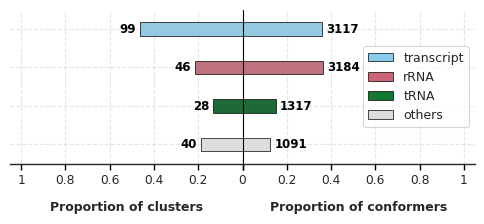

In [54]:
_ = plotBiPanelMetrics(
    df               = dataset_clusters
    , category_col    = 'rna_type_cdrna_grouped_others'
    , group_col       = None
    , col_primary     = 'cluster_id'
    , col_secondary   = 'cluster_size'
    , op_primary      = 'proportion'
    , op_secondary    = 'proportion'
    , orientation     = 'vertical'
    , swap            = True
    , label_primary   = 'Proportion of clusters'
    , label_secondary = 'Proportion of conformers'
    , label_category  = None
    , label_fontsize  = 9
    , palette         = palette_rna_others_muted
    , order           = order_rna_others_types
    , legend_title    = None
    , legend_fontsize = 9
    , show_counts     = True
    , title           = None
    , tick_rotation   = None
    , alpha_primary   = 1.0
    , alpha_secondary = 1.0
    , ax              = None
    , figsize         = (6, 2)
    , save_path       = f"{RESULTS_FIGURES_DIR}Fig2A_bi_proportions_rna_type.png"
)

##### **Figure 2B: Percentage of total ligand-free (apo) and ligand-bound (holo) conformers by RNA type. RNA types are distinguished by color.**

In [55]:
conformers_w_ligands = ligands_w_threshold.loc[lambda df: (df.is_metal == False) & (df.is_crystallization_aid == False)][['cluster_id', 'rna_type_cdrna_grouped_others', 'conformer_id_reduced']].drop_duplicates().reset_index(drop=True)
conformers_w_ligands['has_ligand'] = True
conformers_wo_ligands = dataset_conformers.loc[lambda df: ~df['conformer_id_reduced'].isin(conformers_w_ligands['conformer_id_reduced'])].reset_index(drop=True)
conformers_wo_ligands['rna_type_cdrna_grouped_others'] = conformers_wo_ligands['rna_type_cdrna'].replace(rna_types_grouped_others)
conformers_wo_ligands.drop(columns=['rna_type_cdrna'], inplace=True)
conformers_wo_ligands['has_ligand'] = False
print(conformers_w_ligands.shape, conformers_wo_ligands.shape)
conformers_w_and_wo_ligands = pd.concat([conformers_w_ligands, conformers_wo_ligands], axis=0).reset_index(drop=True)


(6947, 4) (1762, 14)


Figure saved -> /home/martingb/Projects/2025/rna-ligand-paper/results/figures/Fig2B_bi_perc_w_wo_ligand.png (500x500 px @ 300 DPI)


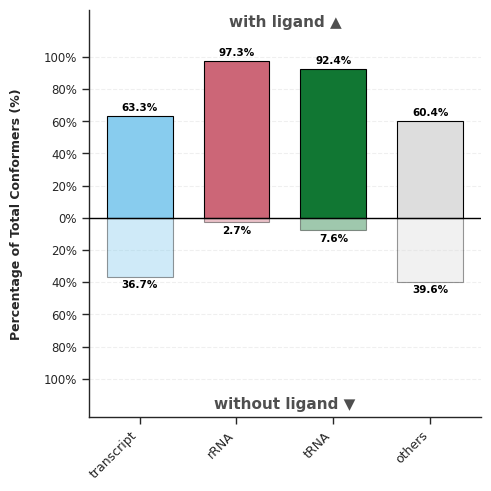

In [56]:
_ = plotRnaConformerLigandBidirectional(
    df            = conformers_w_and_wo_ligands
    , rna_col       = 'rna_type_cdrna_grouped_others'
    , ligand_col    = 'has_ligand'
    , rna_palette   = palette_rna_others_muted
    , xlabel        = None
    , ylabel        = 'Percentage of Total Conformers (%)'
    , title         = None
    , rna_order     = order_rna_others_types
    , alpha_with    = 1.0
    , alpha_without = 0.4
    , ax            = None
    , figsize       = (5, 5)
    , save_path     = f"{RESULTS_FIGURES_DIR}Fig2B_bi_perc_w_wo_ligand.png"
)

##### **Figure 2C: Bi-barplot indicating conformer’s proportion in contact with a given number of unambiguous ligands (right bars). Left bars indicate the proportion of clusters contributing conformers. Numbers on the right and left of the bars indicate the absolute number of conformers and clusters, respectively.**

Figure saved -> /home/martingb/Projects/2025/rna-ligand-paper/results/figures/Fig2C_bi_ligand_counts.png (800x800 px @ 300 DPI)


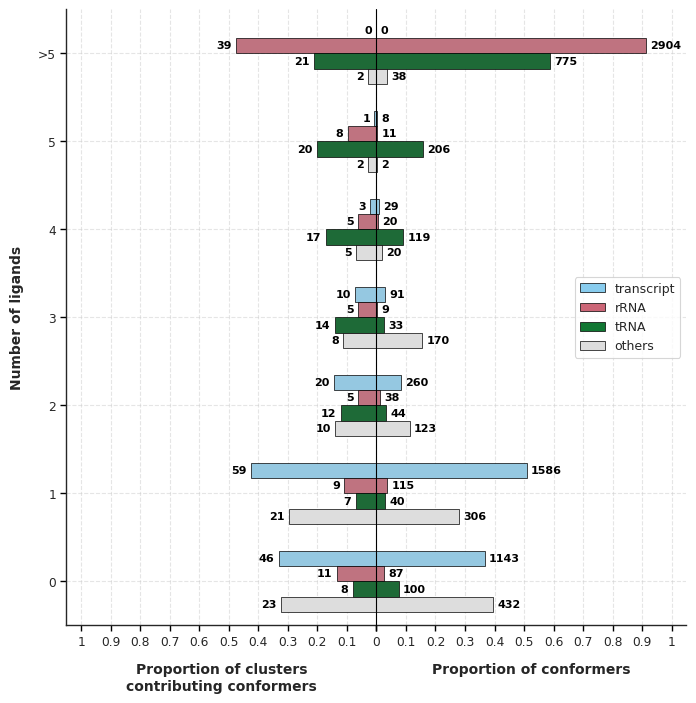

In [57]:
ax_sec, ax_prim = plotBiPanelMetrics(
    df                   = dataset_conformers
    , category_col         = None
    , group_col            = 'rna_type_cdrna_grouped_others'
    , bin_col              = 'ligand_ids'
    , bin_list             = ["0", "1", "2", "3", "4", "5", ">5"]
    , invert_y_order       = None
    , col_primary          = 'conformer_id_reduced'
    , col_secondary        = 'cluster_id'
    , op_primary           = 'proportion'
    , op_secondary         = 'proportion'
    , orientation          = 'vertical'
    , swap                 = False
    , label_category       = 'Number of ligands'
    , label_primary        = 'Proportion of conformers'
    , label_secondary      = 'Proportion of clusters\ncontributing conformers'
    , title                = None
    , legend_title         = None
    , legend_fontsize      = 9
    , label_fontsize       = 10
    , palette              = palette_rna_others_muted
    , group_order          = order_rna_others_types
    , bar_counts_fontsize  = 8
    , xtick_step_primary   = 0.1
    , xtick_step_secondary = 0.1
    , ax                   = None
    , figsize              = (8, 8)
    , save_path            = f"{RESULTS_FIGURES_DIR}Fig2C_bi_ligand_counts.png"
)

##### **Figure 2D: Bubbleplot of maximum RMSD vs RNA Type. Bubble sizes represent ranges in the number of conformers per cluster, as indicated in the legend.**

Figure saved -> /home/martingb/Projects/2025/rna-ligand-paper/results/figures/Fig2D_bubble_rna_type_max_rmsd.png (400x700 px @ 300 DPI)


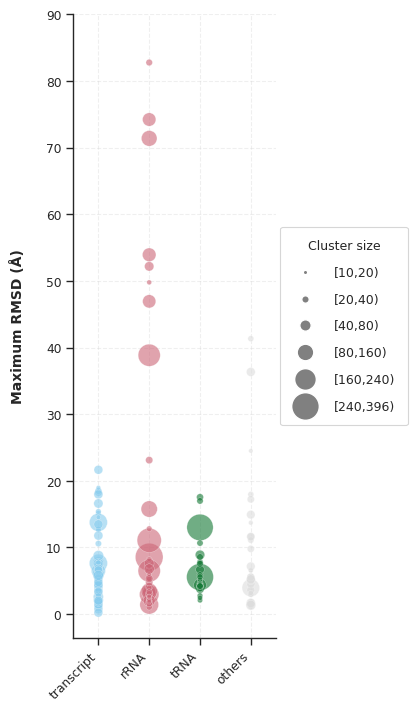

In [58]:
_ = plotCategoricalBubblesRNA(
    df                       = dataset_clusters
    , orientation              = 'vertical'
    , primaryCol               = 'rna_type_cdrna_grouped_others'
    , palette                  = palette_rna_others_muted
    , order_primary            = order_rna_others_types
    , secondaryCol             = 'max_rmsd'
    , sizeCol                  = 'cluster_size'
    , secondaryLabel           = 'Maximum RMSD (Å)'
    , primaryLabel             = None
    , title                    = None
    , legend_title             = 'Cluster size'
    , legend_fontsize          = 9
    , primary_label_fontsize   = 10
    , secondary_label_fontsize = 10
    , figsize                  = (4, 7)
    , save_path                 = f"{RESULTS_FIGURES_DIR}Fig2D_bubble_rna_type_max_rmsd.png"
)

#### **Figure 3: Persistence and overlap of ligand-contact positions across RNA conformers.**

##### **Figure 3A: Boxplot series of the proportion of contact positions with persistence from 0.01 to 1 in ligand-associated conformers across clusters (with at least 10 holo) for transcripts, rRNA and tRNA.**

Figure saved -> /home/martingb/Projects/2025/rna-ligand-paper/results/figures/Fig3A_series_perc.png (1200x400 px @ 300 DPI)


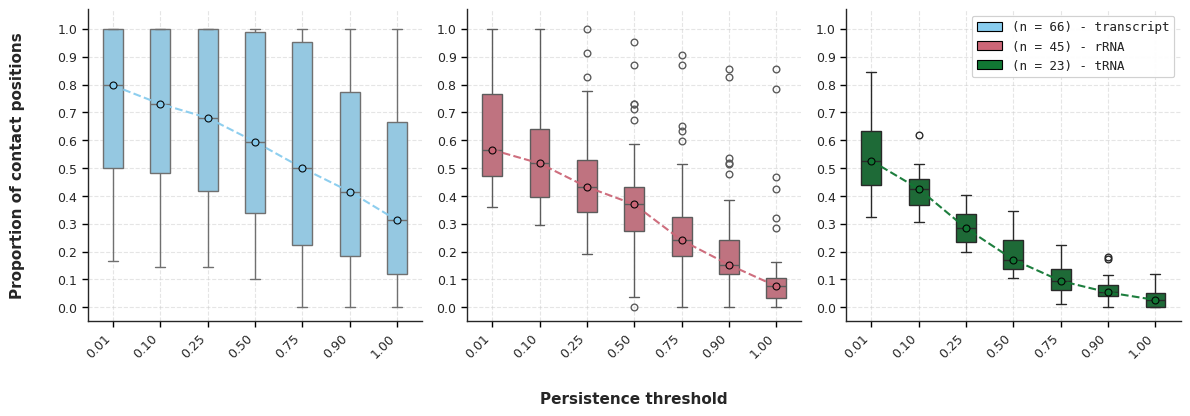

In [59]:
_, _, _ = plotContactPositionProportionSeries(
    df                       = cluster_stats.merge(dataset_clusters[['cluster_id', 'rna_type_cdrna_grouped_others']], on='cluster_id', how='left')
    , cluster_col            = "cluster_id"
    , group_col              = "rna_type_cdrna_grouped_others"
    , persistence_thresholds = [0.01, 0.10, 0.25, 0.5, 0.75, 0.90, 1.00]
    , interaction_suffix     = "no_aid_no_metal"
    , min_holo_conformers    = 10
    , mode                   = "separate"
    , palette                = palette_rna_others_muted
    , xlabel                 = "Persistence threshold"
    , ylabel                 = "Proportion of contact positions"
    , title                  = None
    , group_order            = ["transcript", "rRNA", "tRNA"]
    , showfliers             = True
    , show_medians_line      = True
    , medians_line_kwargs    = {"linewidth": 1.5, "linestyle": "--"}
    , connect_n_min          = 3
    , show_counts            = False
    , stats_mode             = "within_group_vs_baseline"
    , show_stats_legend      = False
    , show_ns                = True
    , legend_stats           = "Mann-Whitney U"
    , show_group_legend      = True
    , legend_in_panel        = 3
    , legend_panel_loc       = "upper right"
    , legend_group_title     = None
    , legend_fontsize        = 9
    , legend_title_fontsize  = 10
    , xlabel_fontsize        = 11
    , ylabel_fontsize        = 11
    , title_fontsize         = 12
    , xlabel_pad             = 45
    , ylabel_pad             = 30
    , xtick_labelsize        = 9
    , ytick_labelsize        = 9
    , tick_length            = 4
    , show_group_annotation  = False
    , facet_ncol             = 3
    , plot_right_margin      = 0.70
    , legend_x_anchor        = 0.72
    , y_pad                  = 0.05
    , return_results         = True
    , ax                     = None
    , figsize                = (12, 4)
    , save_path               = f"{RESULTS_FIGURES_DIR}Fig3A_series_perc.png"
)

##### **Figure 3B: Scatterplot of average Jaccard index vs average contact persistence across clusters (with at least 10 holo) for transcripts, rRNAs, and tRNAs. Cluster 100 is indicated by the black arrow (see Section 3.5).**

In [60]:
def prepare_cluster_jaccard_persistence_dataset(
    cluster_stats_df: pd.DataFrame,
    dataset_pairs_df: pd.DataFrame,
    interaction_suffix: str = "no_aid_no_metal",
    group_col: str = "rna_type_cdrna_grouped_others",
) -> pd.DataFrame:
    """
    Aggregate cluster-level average Jaccard index and position persistence.

    Parameters
    ----------
    cluster_stats_df : pd.DataFrame
        DataFrame containing position-level cluster statistics.
    dataset_pairs_df : pd.DataFrame
        DataFrame containing pairwise conformer calculations.
    interaction_suffix : str, default "no_aid_no_metal"
        Suffix specifying interaction subset columns.
    group_col : str, default "rna_type_cdrna_grouped_others"
        Categorical grouping column for RNA type.

    Returns
    -------
    pd.DataFrame
        Aggregated DataFrame with 'cluster_id', 'avg_jaccard', 'avg_persistence',
        and the specified group column.
    """
    # 1. Compute average Jaccard index per cluster
    jaccard_col = f"jaccard_idx_{interaction_suffix}"
    avg_jaccard = (
        dataset_pairs_df.groupby("cluster_id")[jaccard_col]
        .mean()
        .reset_index(name="avg_jaccard")
    )

    # 2. Compute position persistence and cluster average persistence
    inter_col = f"nb_conformers_with_interactions_{interaction_suffix}"
    holo_col = f"total_holos_{interaction_suffix}"

    stats_df = cluster_stats_df[[
        "cluster_id", group_col, inter_col, holo_col
    ]].copy()

    # Calculate position persistence safely
    stats_df["position_persistence"] = 0.0
    valid_holo_mask = stats_df[holo_col] > 0
    stats_df.loc[valid_holo_mask, "position_persistence"] = (
        stats_df.loc[valid_holo_mask, inter_col] / stats_df.loc[valid_holo_mask, holo_col]
    )

    # Aggregate position persistence across each cluster
    avg_persistence = (
        stats_df.groupby("cluster_id")["position_persistence"]
        .mean()
        .reset_index(name="avg_persistence")
    )

    # Extract single RNA type category per cluster
    cluster_groups = (
        stats_df.groupby("cluster_id")[group_col]
        .first()
        .reset_index()
    )

    # 3. Combine metrics into final cluster dataset
    cluster_summary_df = (
        avg_jaccard
        .merge(avg_persistence, on="cluster_id", how="inner")
        .merge(cluster_groups, on="cluster_id", how="left")
    )

    return cluster_summary_df

In [61]:
# List of clusters ids that have at least 10 holo conformers
clusters_w_gte_10_holo_conformers = dataset_conformers.groupby('cluster_id')\
    .agg(n_holo_conformers=('is_holo', 'sum'))\
    .reset_index()\
    .query('n_holo_conformers >= 10')['cluster_id'].tolist()

In [62]:
# Prepare dataset
cluster_plot_df = prepare_cluster_jaccard_persistence_dataset(
    cluster_stats_df     = cluster_stats.merge(dataset_clusters[['cluster_id', 'rna_type_cdrna_grouped_others']], on='cluster_id')
    , dataset_pairs_df   = dataset_pairs
    , interaction_suffix = "no_aid_no_metal"
    , group_col          = "rna_type_cdrna_grouped_others"
)

Figure saved -> /home/martingb/Projects/2025/rna-ligand-paper/results/figures/Fig3B_scatter_avg_persistence_avg_jaccard.png (1600x400 px @ 300 DPI)


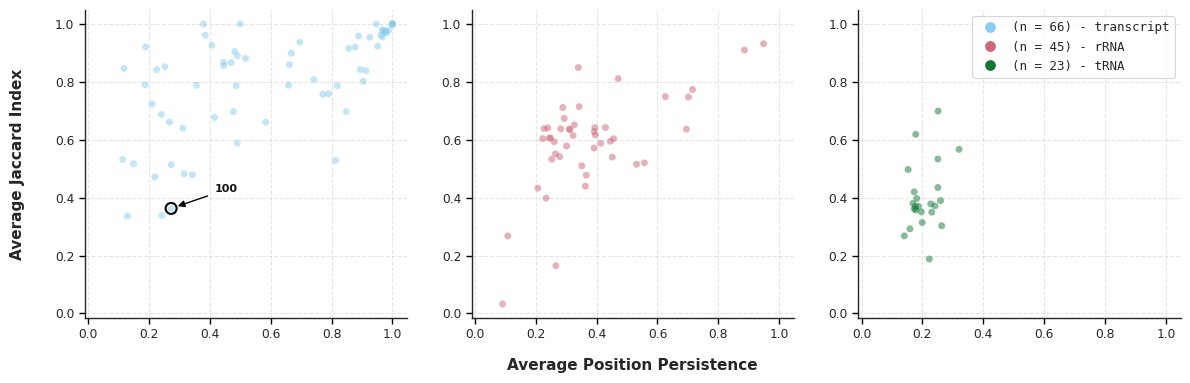

In [63]:
_ = plotFacetedCategoryScatter(
    df                    = cluster_plot_df.loc[lambda df: df.cluster_id.isin(clusters_w_gte_10_holo_conformers)]
    , x_col                 = "avg_persistence"
    , y_col                 = "avg_jaccard"
    , category_col          = "rna_type_cdrna_grouped_others"
    , category_order        = ["transcript", "rRNA", "tRNA"]
    , palette               = palette_rna_others_muted
    , cluster_id_col        = "cluster_id"
    , highlight_clusters    = [100]
    , xlabel                = "Average Position Persistence"
    , xlabel_pad            = 30
    , ylabel                = "Average Jaccard Index"
    , ylabel_pad            = 20
    , show_legend           = True
    , legend_title          = None
    , show_correlation      = False
    , correlation_method    = "spearman"
    , correlation_display   = "legend"
    , legend_stats_title    = "Spearman Test"
    , legend_in_panel       = 3
    , legend_panel_loc      = "upper right"
    , legend_title_fontsize = 10
    , legend_fontsize       = 9
    , show_regression_line  = False
    , confidence_interval   = 95
    , show_category_badge   = False
    , show_scatter          = True
    , share_scales          = True
    , facet_ncol            = 3
    , plot_right_margin     = 0.81
    , legend_x_anchor       = 0.82
    , figsize               = (16, 4)
    , save_path             = f"{RESULTS_FIGURES_DIR}Fig3B_scatter_avg_persistence_avg_jaccard.png"
)

#### **Figure 4: Ligand-associated conformational diversity of HIV-1 TAR RNA. Molecular graphics were prepared using PyMOL, version 3.2.0a**

##### **Figure 4A: Cartoon representation of a structural alignment of conformers 1anr_1_A_6 (orange) and 1anr_1_A_8 (blue), with RMSD=11.44 Å.**

Figure 4A is provided as PNG file in the `results/figures` directory.

##### **Figure 4B: Cartoon representation of a structural alignment of conformers 1anr_1_A_8 (blue) and 2kx5_1_A_3 (green), with RMSD=4.00 Å. Peptide ligand is shown in pink.**

Figure 4B is provided as PNG file in the `results/figures` directory.

##### **Figure 4C: Barplot showing RMSD per position between conformers 1anr_1_A_6 and 2kx5_1_A_3 (orange bars); 1anr8_1_A_8 and 2kx5_1_A_3 (purple bars); 1anr_1_A_6 and 1anr_1_A_8 (green bars).**

In [64]:
dataset_residues_w_interactions_100 = dataset_residues_w_interactions.loc[lambda df: df.cluster_id == 100].copy()
dataset_pairs_100 = dataset_pairs.loc[lambda df: df.cluster_id == 100].copy()

In [65]:
selected_conformers_apos = ['1anr_1_A_6', '1anr_1_A_8']
selected_conformers_holos = ['2kx5_1_A_3']
selected_conformers = selected_conformers_apos + selected_conformers_holos

In [66]:
dataset_residues_w_interactions_100_selection = dataset_residues_w_interactions_100.loc[lambda df: df.conformer_id_reduced.isin(selected_conformers)].copy()
dataset_pairs_100_selection = dataset_pairs_100.loc[lambda df: ( (df.conformer_id_1.isin(selected_conformers) & df.conformer_id_2.isin(selected_conformers)))].copy()

In [67]:
conformers_to_see = dataset_pairs_100_selection[['conformer_id_1', 'conformer_id_2']].stack().unique().tolist()
cluster_100_pairs = get_pairs_w_residues( pairs = dataset_pairs_100_selection
                                        , dataset_residues_w_interactions = conformer_stats.loc[lambda df: df['conformer_id_reduced'].isin(conformers_to_see)])

In [68]:
cluster_100_pairs['pair'] = cluster_100_pairs.apply(lambda row: f"{row.conformer_id_1} - {row.conformer_id_2}", axis=1)
# 'auth_seq_id_1' is equals to 'auth_seq_id_2' for all residues, so we can use only one of them to plot the residues
cluster_100_pairs['residue_label'] = (cluster_100_pairs['one_letter_code'].astype(str) + ' ' + cluster_100_pairs['label_seq_id_aligned'].astype(str) + ' (' + cluster_100_pairs['auth_seq_id_1'].astype(str) + ')')

In [69]:
def merge_c3_prime_rmsd_vectorized(df_pairs: pd.DataFrame, df_rmsd_source: pd.DataFrame) -> pd.DataFrame:
    """
    Vectorizes the extraction of C3' RMSD values for all conformer pairs.

    Reshapes the RMSD matrix into a long format lookup Series with a MultiIndex,
    ensuring safe and fast mapping without altering the original DataFrame's shape.

    Parameters:

                * df_pairs : pd.DataFrame The main dataset containing pairs and 'auth_seq_id_1'.
                * df_rmsd_source : pd.DataFrame The reference DataFrame containing RMSD columns.

    Observation:

        - Uses pd.melt() to transition from wide to long format.
        - Splits column names into discrete conformer keys.
        - Maps data using both (conf_1, conf_2) and (conf_2, conf_1) permutations.

    Returns:
        pd.DataFrame. The original df_pairs with the optimized 'rmsd_c3_prime' column added.
    """
    # 1. Transform RMSD matrix from wide to long format
    df_long = df_rmsd_source.melt(
        id_vars=["res_num"], var_name="rmsd_column", value_name="rmsd_value"
    )

    # 2. Extract conformer names from column strings: 'rmsd-CONF1-vs-CONF2'
    df_long[["conf_a", "conf_b"]] = (
        df_long["rmsd_column"]
        .str.replace("rmsd-", "", regex=False)
        .str.split("-vs-", expand=True)
    )

    # 3. Create a fast MultiIndex lookup Series mapping (res_num, conf_a, conf_b) -> rmsd_value
    lookup_series = df_long.set_index(["res_num", "conf_a", "conf_b"])[
        "rmsd_value"
    ]

    # 4. Generate lookup keys from the main pairs DataFrame
    res_keys = df_pairs["auth_seq_id_1"]
    c1_keys = df_pairs["conformer_id_1"]
    c2_keys = df_pairs["conformer_id_2"]

    # 5. Map Permutation 1: Match exactly (conf1 == conf_a) AND (conf2 == conf_b)
    index_perm1 = pd.MultiIndex.from_arrays([res_keys, c1_keys, c2_keys])
    rmsd_perm1 = index_perm1.map(lookup_series)

    # 6. Map Permutation 2: Match inverted (conf1 == conf_b) AND (conf2 == conf_a)
    index_perm2 = pd.MultiIndex.from_arrays([res_keys, c2_keys, c1_keys])
    rmsd_perm2 = index_perm2.map(lookup_series)

    # 7. Coalesce results: Take perm1, fill missing values with perm2
    df_pairs["rmsd_c3_prime"] = pd.Series(rmsd_perm1).fillna(
        pd.Series(rmsd_perm2)
    ).values

    return df_pairs

In [70]:
cluster_100_pairs = merge_c3_prime_rmsd_vectorized(cluster_100_pairs, df_rmsd_c3_prime)

Figure saved -> /home/martingb/Projects/2025/rna-ligand-paper/results/figures/Fig4C_pairs_rmsd_c3_prime.png (2000x500 px @ 300 DPI)


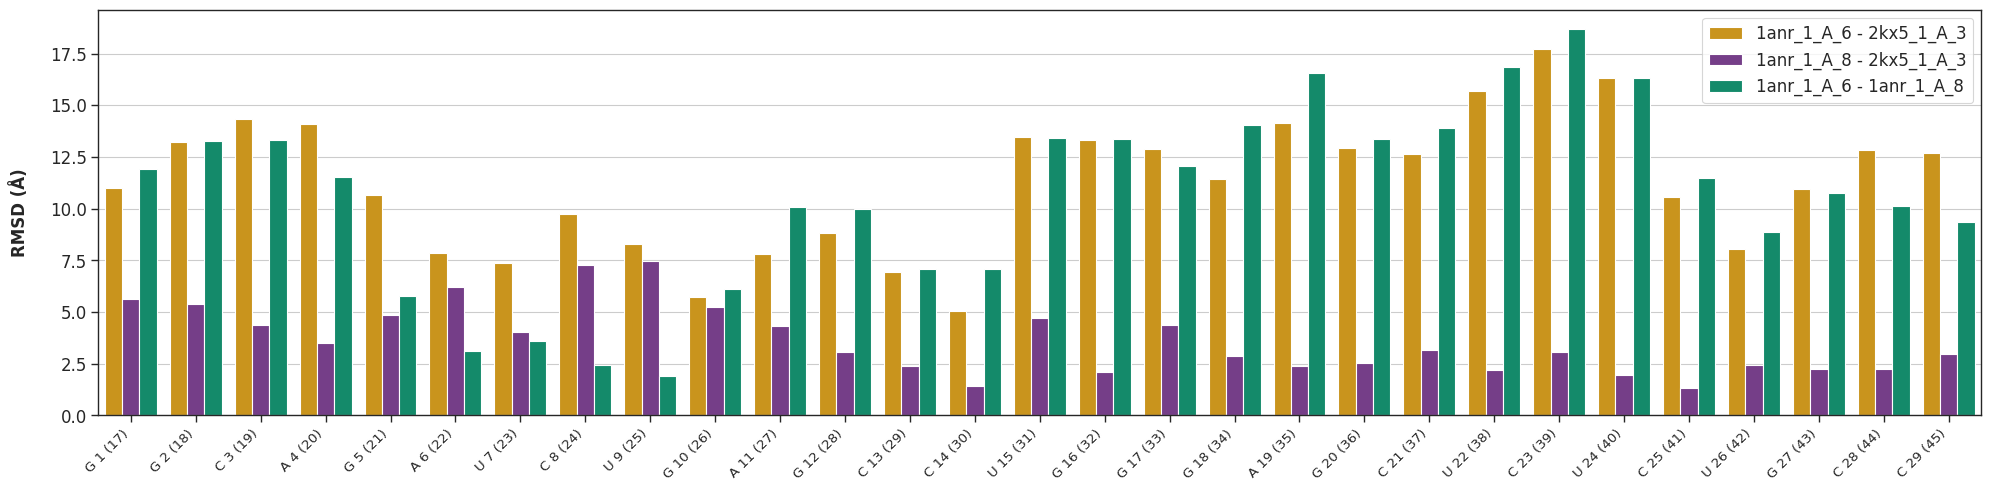

In [71]:
_ = plotGroupedBarDistribution(
    df                       = cluster_100_pairs
    , x_col                  = 'residue_label'
    , y_col                  = 'rmsd_c3_prime'
    , hue_col                = 'pair'
    , hue_order              = order_pairs
    , palette                = colors_pairs
    , xlabel                 = None
    , ylabel                 = "RMSD (Å)"
    , y_step_min             = 2.5
    , ylabel_fontsize        = 12
    , yticks_fontsize        = 12
    , legend_labels_fontsize = 12
    , title                  = None
    , save_path              = f"{RESULTS_FIGURES_DIR}Fig4C_pairs_rmsd_c3_prime.png"
)

##### **Figure 4D: Barplot showing contact persistence per position for all holo conformers of cluster 100.**

In [72]:
df_100 = cluster_stats.loc[lambda df: (df['cluster_id'] == 100)].copy()
# values from 17 to 45
df_100['auth_seq_id'] = range(17, 46)
df_100['residue_label'] = (df_100['one_letter_code'].astype(str) + ' ' + df_100['label_seq_id_aligned'].astype(str) + ' (' + df_100['auth_seq_id'].astype(str) + ')')

Figure saved -> /home/martingb/Projects/2025/rna-ligand-paper/results/figures/Fig4D_cluster_100_percentage.png (2000x500 px @ 300 DPI)


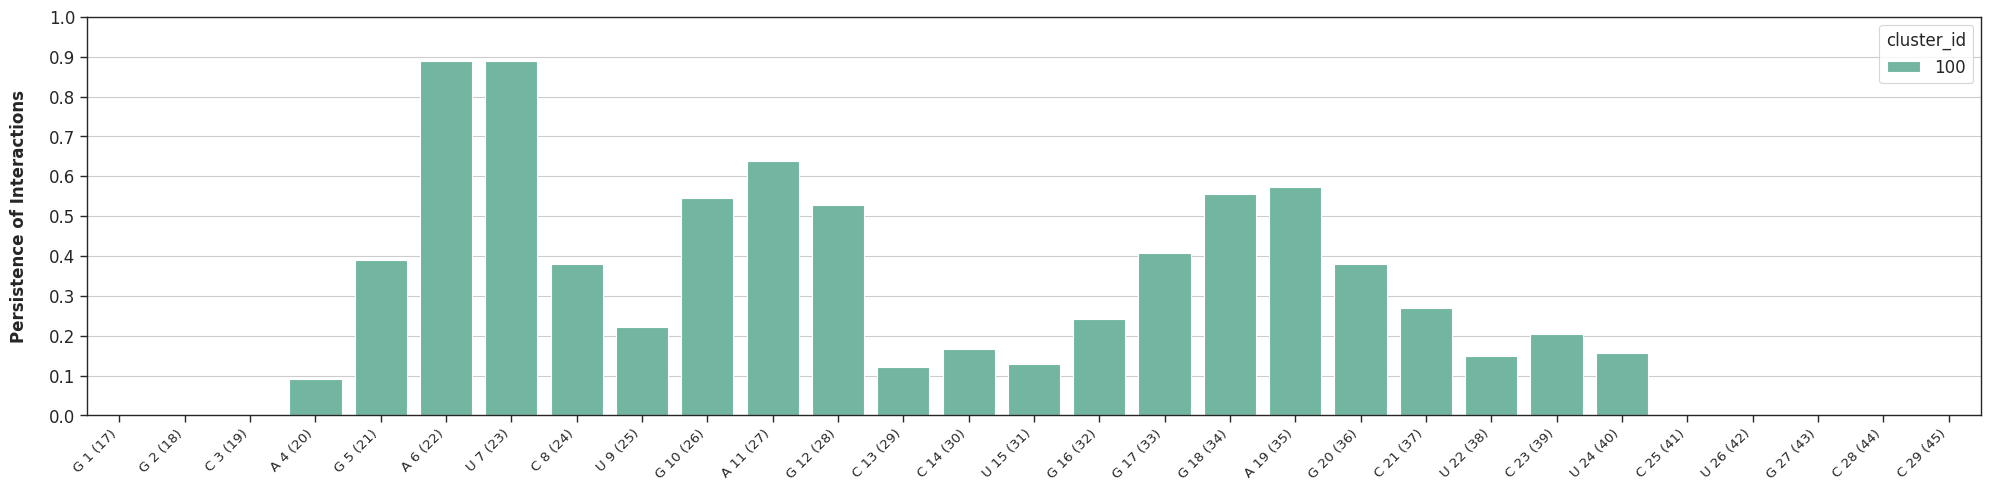

In [73]:
_ = plotGroupedBarDistribution(
    df                       = df_100
    , x_col                  = 'residue_label'
    , y_col                  = 'proportional_holo_conservation_score_no_aid_no_metal'
    , hue_col                = 'cluster_id'
    , palette                = 'Set2'
    , xlabel                 = None
    , ylabel                 = 'Persistence of Interactions'
    , title                  = None #'Interactions vs Residues'
    , legend_title           = 'cluster_id'
    , y_lim                  = (0, 1)
    , y_step_min             = 0.1
    , ylabel_fontsize        = 12
    , yticks_fontsize        = 12
    , legend_title_fontsize  = 12
    , legend_labels_fontsize = 12
    , arrow_targets          = None
    , save_path              = f"{RESULTS_FIGURES_DIR}Fig4D_cluster_100_percentage.png"
)

##### **Figure 4E: Barplot showing contact persistence per position for the subset of holo conformers 2kx5_1_A_1 to 2kx5_1_A_10. Arrows above the bars indicate ligand-contact positions in 2kx5_1_A_3.**

In [74]:
df_100_2kx5_1_A = conformer_stats.loc[lambda df: (df['cluster_id'] == 100) & (df['conformer_id_reduced'].str.startswith('2kx5_1_A'))].copy()
stats_2kx5_1_A = (
    df_100_2kx5_1_A.groupby(["cluster_id", "label_seq_id_aligned", "one_letter_code", "auth_seq_id"])
        .agg(holo_conservation_score_no_aid_no_metal=("interaction_count_no_aid_no_metal", lambda x: (x > 0).sum()))
        .reset_index()
)

In [75]:
# Normalization of contacts by the total number of holo conformers
nb_holos_2kx5_1_A = df_100_2kx5_1_A.loc[lambda df: df['interaction_count_no_aid_no_metal'] > 0].conformer_id_reduced.nunique()
stats_2kx5_1_A[f"proportional_holo_conservation_score_no_aid_no_metal"] = stats_2kx5_1_A["holo_conservation_score_no_aid_no_metal"] / nb_holos_2kx5_1_A

# Add two columns to make it easier to plot the residues and identify the group
stats_2kx5_1_A['group'] = '2kx5_1_A_1 to 2kx5_1_A_10'
stats_2kx5_1_A['residue_label'] = (stats_2kx5_1_A['one_letter_code'].astype(str) + ' ' + stats_2kx5_1_A['label_seq_id_aligned'].astype(str) + ' (' + stats_2kx5_1_A['auth_seq_id'].astype(str) + ')')

In [76]:
# Arrows position for the plot
interaction_poss = conformer_stats.loc[lambda df: (df.conformer_id_reduced.isin(['2kx5_1_A_3']) &\
                                                (df.interaction_count_no_aid_no_metal > 0))].label_seq_id_aligned.unique().tolist()

Figure saved -> /home/martingb/Projects/2025/rna-ligand-paper/results/figures/Fig4E_2kx5_1_A_confs_percentage.png (2000x500 px @ 300 DPI)


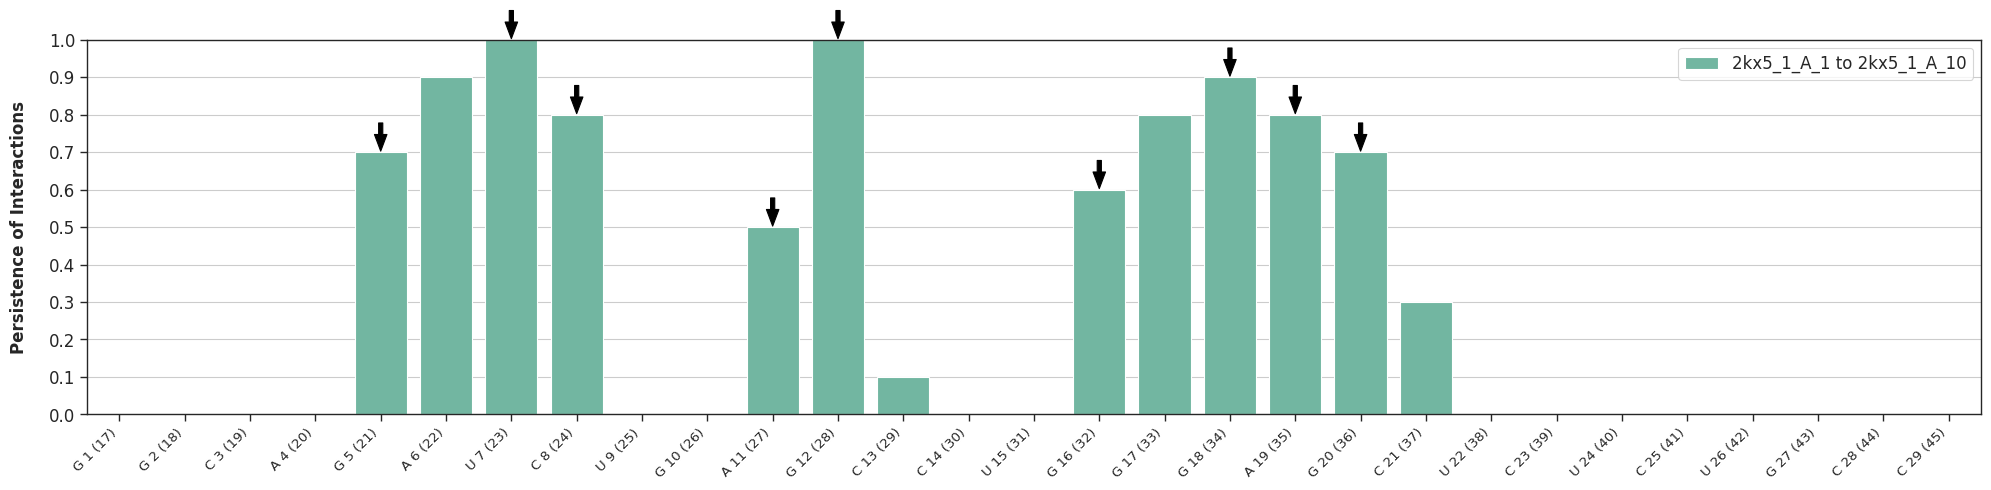

In [77]:
_ = plotGroupedBarDistribution(
    df                       = stats_2kx5_1_A
    , x_col                  = 'residue_label'
    , y_col                  = 'proportional_holo_conservation_score_no_aid_no_metal'
    , hue_col                = 'group'
    , palette                = 'Set2'
    , xlabel                 = None
    , ylabel                 = 'Persistence of Interactions'
    , title                  = None # 'Interactions vs Residues'
    , legend_title           = None
    , y_lim                  = (0, 1)
    , y_step_min             = 0.1
    , ylabel_fontsize        = 12
    , yticks_fontsize        = 12
    , legend_labels_fontsize = 12
    , arrow_targets          = interaction_poss
    , save_path              = f"{RESULTS_FIGURES_DIR}Fig4E_2kx5_1_A_confs_percentage.png"
)


### **Supplementary Tables**

#### **Supplementary Table 1: Artifacts and structural metals removed from original_dataset.**

Supplementary Table 1 is provided as a TSV file in the `results/tables` directory.

#### **Supplementary Table 2: Descriptive dataset statistics (initial_dataset). The table provides unique identifiers for each ligand.**

In [78]:
table = build_descriptive_statistics_table(
    df_clusters          = dataset_clusters_initial
    , df_conformers      = dataset_conformers_initial
    , df_pairs           = dataset_pairs_initial
    , df_ligands         = ligands_w_threshold_initial.loc[lambda df: (df.is_metal == False) & (df.is_crystallization_aid == False)]
    , cluster_col        = 'cluster_id'
    , rna_col            = "rna_type_cdrna_grouped_others"
    , ligand_ids_col     = 'identifier'
    , ligand_type_col    = 'partner_rcsb_type_grouped'
    , include_resolution = False
)

In [79]:
initial_table = table[order_rna_others_types].reset_index()
initial_table.columns.name = None

In [ ]:
os.makedirs(RESULTS_TABLES_DIR, exist_ok=True)
saveTable( df         = initial_table
        , outputDir   = f"{RESULTS_TABLES_DIR}"
        , table_name   = "Supplementary_Table2_descriptive_statistics_initial_dataset"
        , a_separator = "\t"
        , na_rep      = ""
        , compress    = True )

#### **Supplementary Table 3: Descriptive dataset statistics (final_dataset). The table provides unique identifiers for each ligand.**

In [81]:
table = build_descriptive_statistics_table(
    df_clusters        = dataset_clusters
    , df_conformers      = dataset_conformers
    , df_pairs           = dataset_pairs
    , df_ligands         = ligands_w_threshold.loc[lambda df: (df.is_metal == False) & (df.is_crystallization_aid == False)]
    , rna_col            = "rna_type_cdrna_grouped_others"
    , cluster_col        = 'cluster_id'
    , ligand_ids_col     = 'identifier'
    , ligand_type_col    = 'partner_rcsb_type_grouped'
    , include_resolution = False
)

In [82]:
final_table = table[order_rna_others_types].reset_index()
final_table.columns.name = None

In [ ]:
os.makedirs(RESULTS_TABLES_DIR, exist_ok=True)
saveTable( df         = final_table
        , outputDir   = f"{RESULTS_TABLES_DIR}"
        , table_name   = "Supplementary_Table3_descriptive_statistics_final_dataset"
        , a_separator = "\t"
        , na_rep      = ""
        , compress    = True )

### **Supplementary Figures**

#### **Supplementary Figure 1: Venn diagram showing the overlap of experimental methods across clusters. The numbers indicate clusters determined by each method or by combinations of them. XRD, CEM, and NMR are shown in green, orange, and purple, respectively.**

Figure saved -> /home/martingb/Projects/2025/rna-ligand-paper/results/figures/FigS1_venn_experimental_methods.png (600x600 px @ 300 DPI)


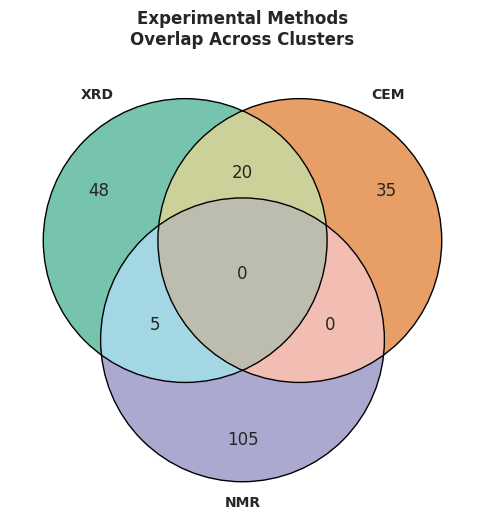

In [84]:
_ = plotExperimentalMethodsVenn(
    df                = dataset_clusters
    , palette         = palette_method
    , draw_circles    = True
    , show_zeros      = True
    , title           = "Experimental Methods\nOverlap Across Clusters"
    , title_fontsize  = 12
    , label_fontsize  = 10
    , number_fontsize = 12
    , ax              = None
    , figsize         = (6, 6)
    , save_path       = f"{RESULTS_FIGURES_DIR}FigS1_venn_experimental_methods.png"
)

#### **Supplementary Figure 2: UpSet plot showing the overlap of ligand types across clusters. The numbers indicate clusters containing each ligand type and the size of their intersections. Ligand types are shown as proteins (light blue), RNA (dark red), nonpolymeric ligands (dark yellow), and others (dark blue).**

In [85]:
# Dataframe preparation
df_indicators = prepareClusterIndicators(
    df               = ligands_w_threshold.loc[lambda df: (df.is_metal == False) & (df.is_crystallization_aid == False)]
    , cluster_id_col = "cluster_id"
    , category_col   = "partner_rcsb_type_grouped"
    , categories     = order_ligand_types
)

Figure saved -> /home/martingb/Projects/2025/rna-ligand-paper/results/figures/FigS2_upset_ligand_types.png (800x444 px @ 300 DPI)


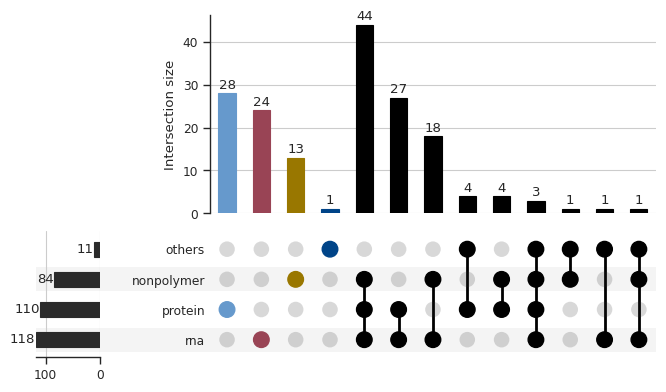

In [86]:
_ = plotClusterUpSet(
    indicator_df               = df_indicators
    , orientation              = "horizontal"
    , categories               = order_ligand_types
    , palette                  = palette_biomolecule_others_medium_contrast
    , prioritize_singles       = True
    , sort_singles_by          = "category_order"
    , multi_intersection_color = "#000000"
    , title                    = None
    , title_fontsize           = 12
    , show_counts              = True
    , figsize                  = (15, 5)
    , save_path                = f"{RESULTS_FIGURES_DIR}FigS2_upset_ligand_types.png"
)

#### **Supplementary Figure 3: Barplot of the (log) number of unique ligands by RNA type. Ligand types are distinguished by color.**

In [87]:
df_ligands_subset = ligands_w_threshold.loc[lambda df: (df.is_metal == False) & (df.is_crystallization_aid == False)][['rna_type_cdrna_grouped_others', 'partner_rcsb_type_grouped', 'identifier']].drop_duplicates()\
                            .groupby(['rna_type_cdrna_grouped_others', 'partner_rcsb_type_grouped'])\
                            .agg({'identifier': 'nunique'})\
                            .sort_values(['identifier'], ascending=False)\
                            .rename(columns={'identifier': 'unique_ligand_count'})\
                            .reset_index()

Figure saved -> /home/martingb/Projects/2025/rna-ligand-paper/results/figures/FigS3_log_ligand_in_rna_type.png (1000x550 px @ 300 DPI)


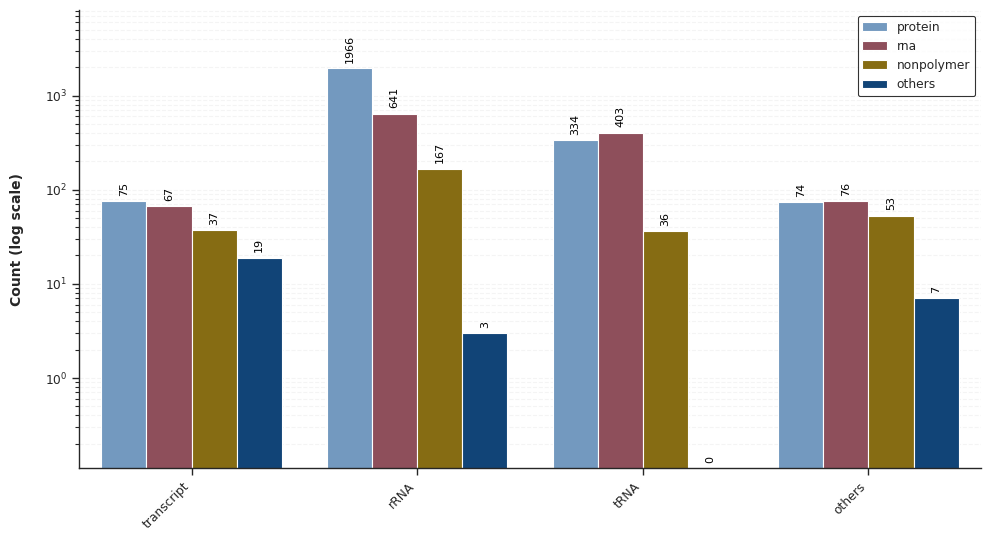

In [88]:
_ = plotRnaPartnerFrequencySum(
    df              = df_ligands_subset
    , values        = 'unique_ligand_count'
    , rna_col       = 'rna_type_cdrna_grouped_others'
    , partner_col   = 'partner_rcsb_type_grouped'
    , palette       = palette_biomolecule_others_medium_contrast
    , xlabel        = None
    , ylabel        = 'Count (log scale)'
    , title         = None
    , legend_title  = None
    , rna_order     = order_rna_others_types
    , partner_order = order_ligand_types
    , ax            = None
    , figsize       = (10, 5.5)
    , save_path     = f"{RESULTS_FIGURES_DIR}FigS3_log_ligand_in_rna_type.png"
)

#### **Supplementary Figure 4: Bi-barplot indicating conformer’s proportion in contact determined by each experimental technique with a given number of unambiguous ligands (right bars). Left bars indicate the proportion of clusters contributing conformers. Numbers on the right and left of the bars indicate the absolute numbers of conformers and contributing clusters, respectively.**

Figure saved -> /home/martingb/Projects/2025/rna-ligand-paper/results/figures/FigS4_bi_ligand_counts_by_method.png (800x800 px @ 300 DPI)


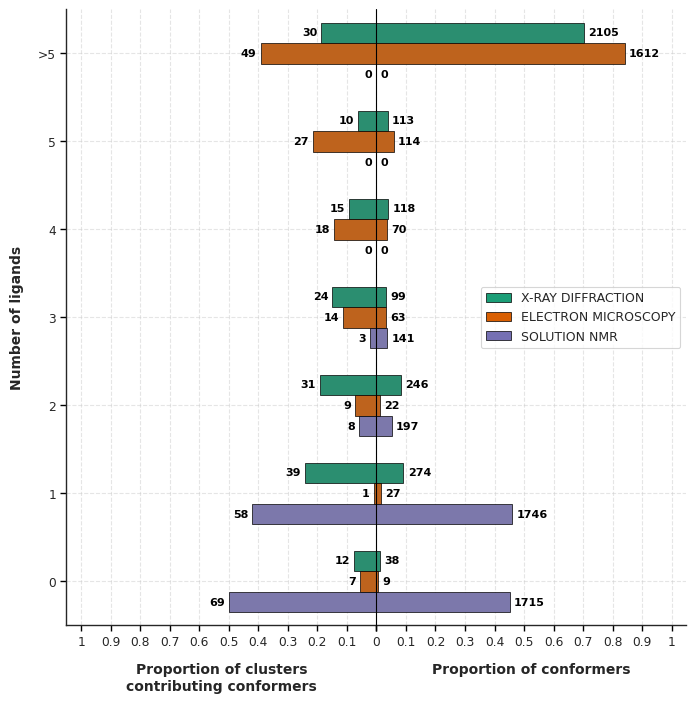

In [89]:
_, _ = plotBiPanelMetrics(
    df                     = dataset_conformers
    , category_col         = None
    , group_col            = 'method'
    , bin_col              = 'ligand_ids'
    , bin_list             = ["0", "1", "2", "3", "4", "5", ">5"]
    , invert_y_order       = None
    , col_primary          = 'conformer_id_reduced'
    , col_secondary        = 'cluster_id'
    , op_primary           = 'proportion'
    , op_secondary         = 'proportion'
    , orientation          = 'vertical'
    , swap                 = False
    , label_category       = 'Number of ligands'
    , label_primary        = 'Proportion of conformers'
    , label_secondary      = 'Proportion of clusters\ncontributing conformers'
    , title                = None
    , legend_title         = None
    , legend_fontsize      = 9
    , label_fontsize       = 10
    , palette              = palette_method
    , group_order          = order_method
    , bar_counts_fontsize  = 8
    , xtick_step_primary   = 0.1
    , xtick_step_secondary = 0.1
    , ax                   = None
    , figsize              = (8, 8)
    , save_path            = f"{RESULTS_FIGURES_DIR}FigS4_bi_ligand_counts_by_method.png"
)

#### **Supplementary Figure 5: Boxplots showing the distribution of pairwise RMSD values for structures determined by XRD, CEM, and NMR.**

Figure saved -> /home/martingb/Projects/2025/rna-ligand-paper/results/figures/FigS5_boxplot_rmsd_by_method.png (600x600 px @ 300 DPI)


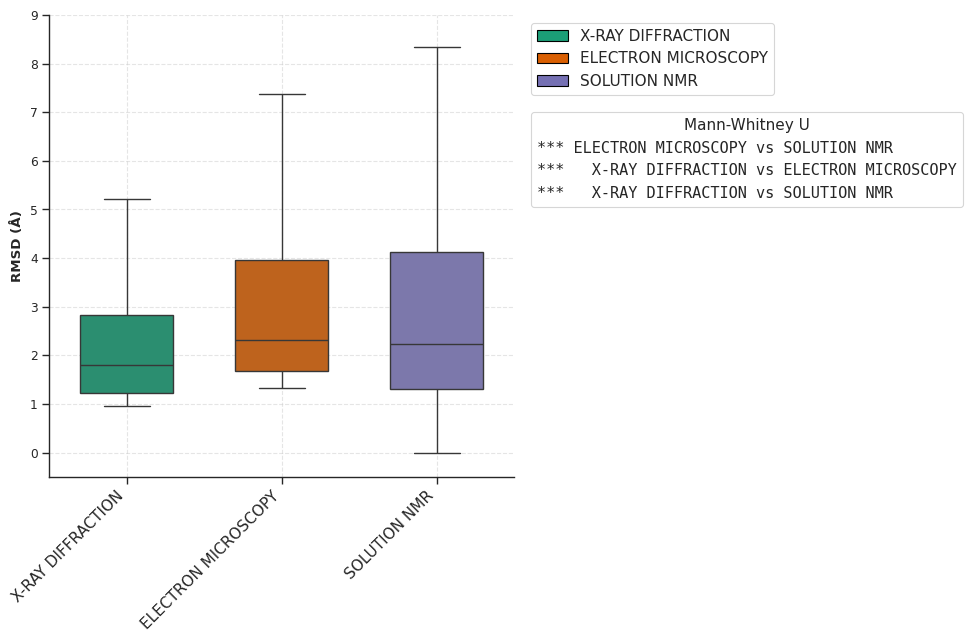

In [90]:
_ = plot_boxplot_comparison(
    df                         = dataset_pairs
    , value_col                = "rmsd"
    , category_col             = "method_1"
    , status_col               = None
    , palette_category         = palette_method
    , palette_status           = None
    , xlabel                   = None
    , ylabel                   = "RMSD (Å)"
    , title                    = None
    , legend_title             = None
    , category_order           = order_method
    , status_order             = None
    , show_all                 = False
    , all_label                = None
    , all_color                = '#DDDDDD'
    , y_tick_interval          = 1
    , xtick_rotation           = 45
    , xtick_size               = 11
    , horizontal_alignment     = "right"
    , use_log                  = False
    , show_outliers            = False
    , status_opacity_factor    = 0.6
    , ax                       = None
    , add_stats_mann_whitney_u = True
    , legend_title_fontsize    = 11
    , legend_label_fontsize    = 11
    , show_ns                  = True
    , figsize                  = (6, 6)
    , save_path                = f"{RESULTS_FIGURES_DIR}/FigS5_boxplot_rmsd_by_method.png"
)

#### **Supplementary Figure 6:  2D secondary structure representations of 1anr_1_A_6, 1anr_1_A_8 and 2kx5_1_A_3. Images extracted from CoDNaS-RNA.**

Supplementary Figure 6 is provided as PNG and SVG files in the `results/figures` directory.

#### **Supplementary Figure 7: Boxplots showing the RMSD distribution of holo-holo, apo-apo and apo-holo pairs for cluster 100.**

Figure saved -> /home/martingb/Projects/2025/rna-ligand-paper/results/figures/FigS7_boxplot_rmsd_by_forms_type_cluster_100.png (600x600 px @ 300 DPI)


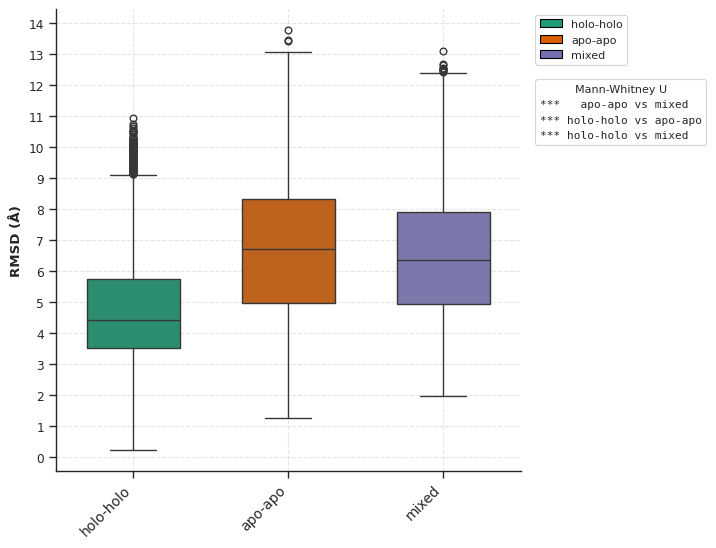

In [91]:
_ = plot_boxplot_comparison(
    df                         = dataset_pairs.loc[lambda df: df.cluster_id == 100]
    , value_col                = "rmsd"
    , category_col             = "forms_type"
    , status_col               = None
    , palette_category         = palette_forms
    , palette_status           = None
    , xlabel                   = None
    , ylabel                   = "RMSD (Å)"
    , title                    = None
    , legend_title             = None
    , category_order           = order_forms
    , status_order             = None
    , show_all                 = False
    , all_label                = None
    , all_color                = '#DDDDDD'
    , y_tick_interval          = 1
    , xtick_rotation           = 45
    , xtick_size               = 10
    , horizontal_alignment     = "right"
    , use_log                  = False
    , show_outliers            = True
    , status_opacity_factor    = 0.6
    , ax                       = None
    , add_stats_mann_whitney_u = True
    , legend_title_fontsize    = 8
    , legend_label_fontsize    = 8
    , show_ns                  = True
    , figsize                  = (6, 6)
    , save_path                = f"{RESULTS_FIGURES_DIR}/FigS7_boxplot_rmsd_by_forms_type_cluster_100.png"
)

# **Bottom of notebook**